In [694]:
import json

import numpy as np
import pandas as pd

import seaborn as sns

from matplotlib import pyplot as plt


In [695]:
non_dataset_exercises = ["Ab Crunch Machine","Leg Raises",
"Side Crunches",
"Ab Roll Outs",
"Preacher Curls",
"Back Extensions",
"Pull-ups",
"Chest Fly Machine",
"Chest Press Machine",
"Cable Chest Fly",
"Bulgarian Split Squat",
"Romanian Deadlifts",
"Stiff-Leg Deadlifts",
"Machine Deadlifts",
"Single Leg Romanian Deadlifts",]


In [696]:
EXERCISE_GROUPS = {
    "Ab Crunch Machine":        "Vēders",
    "Crunches":                 "Vēders",
    "Leg Raises":               "Vēders",
    "Plank":                    "Vēders",
    "Ab Roll Outs":             "Vēders",
    "Cable Ab Crunches":        "Vēders",

    "Dumbbell Bicep Curls":     "Bicepsi",
    "Hammer Curls":             "Bicepsi",
    "Incline Dumbbell Curls":   "Bicepsi",
    "Preacher Curls":           "Bicepsi",
    "Tricep Pushdowns":         "Tricepsi",
    "Cable Overhead Extensions": "Tricepsi",
    "Dips":                     "Tricepsi",

    "Assisted Pull-ups":        "Mugura",
    "Cable Rows":               "Mugura",
    "Lat Pulldowns":            "Mugura",
    "Row Machine":              "Mugura",
    "Straight Arm Lat Pulldowns": "Mugura",
    "Back Extensions":          "Mugura",
    "Pull-ups":                 "Mugura",

    "Bench Press":              "Krūtis",
    "Chest Fly Machine":        "Krūtis",
    "Chest Press Machine":      "Krūtis",
    "Dumbbell Bench Press":     "Krūtis",
    "Dumbell Chest Flys":       "Krūtis",
    "Cable Chest Fly":          "Krūtis",
    "Incline Dumbbell Bench Press": "Krūtis",

    "Barbell Squats":           "Kājas",
    "Bulgarian Split Squat":    "Kājas",
    "Deadlifts":                "Kājas",
    "Goblet Squats":            "Kājas",
    "Lunges":                   "Kājas",
    "Romanian Deadlifts":       "Kājas",
    "Stiff-Leg Deadlifts":      "Kājas",
    "Machine Deadlifts":        "Kājas",
    "Single Leg Romanian Deadlifts": "Kājas",

    "Barbell Overhead Press":   "Pleci",
    "Dumbbell Lateral Raises":  "Pleci",
    "Dumbbell Overhead Press":  "Pleci",
    "Machine Lateral Raises":   "Pleci",
    "Cable Lateral Raises":     "Pleci",

}

GROUP_ORDER = ["Vēders", "Bicepsi", "Tricepsi", "Mugura", "Krūtis", "Kājas", "Pleci"]

# Load methods

# Load sessions

In [697]:
def load_sessions(session_paths, ignore_list=None):
    ignore_list = ignore_list or []

    all_session_windows = []
    all_session_events = []
    all_info = []

    session_id = 1

    for path in session_paths:
        accel, gyro, clf, annotations, info = load_recording(path)

        events_watch_time = convert_events_to_watch_time(
            annotations,
            info
        )

        clf, events = remove_ignored_exercises(
            clf,
            events_watch_time,
            ignore_list=ignore_list
        )

        for event in events:
            event["group"] = EXERCISE_GROUPS.get(event["name"], "Unknown")
            event["session"] = path
            event["session_id"] = session_id

        clf = add_ground_truth(clf, events)
        clf["session"] = path
        clf["session_id"] = session_id

        session_id += 1

        all_session_windows.append(clf)
        all_session_events.extend(events)
        all_info.append(info)

    return all_session_windows, all_session_events, all_info

def load_recording(path):
    accel = pd.read_csv(f"{path}/accel.csv")
    gyro = pd.read_csv(f"{path}/gyro.csv")
    classification = pd.read_csv(f"{path}/classification.csv")

    # Parse serialized IMU windows
    classification["window_data"] = classification["window_data"].apply(parse_window_data)

    with open(f"{path}/annotations.json") as f:
        annotations = json.load(f)

    with open(f"{path}/info.txt") as f:
        lines = f.read().splitlines()

    info = {
        "watch_start_timestamp": int(lines[0].split("=")[1]),
        "watch_end_timestamp": int(lines[2].split("=")[1]),
    }

    return accel, gyro, classification, annotations, info

def parse_window_data(window_str, expected_channels=6):
    """
    Converts one serialized window string into a NumPy array.

    Input format:
    'a1|a2|a3|g1|g2|g3;a1|a2|a3|g1|g2|g3;...'

    Output shape:
    (window_length, 6)
    """
    if pd.isna(window_str):
        raise ValueError("window_data is missing")

    rows = [row for row in window_str.strip().split(";") if row.strip()]

    window = []
    for row in rows:
        values = [float(value) for value in row.split("|")]

        if len(values) != expected_channels:
            raise ValueError(f"Expected {expected_channels} channels, got {len(values)}")

        window.append(values)

    return np.array(window, dtype=np.float32)

def convert_events_to_watch_time(annotations, info, linear=False):
    phone_start = annotations["phoneStartTimestamp"]
    phone_end = annotations["phoneEndTimestamp"]

    watch_start = info["watch_start_timestamp"]
    watch_end = info["watch_end_timestamp"]

    events_watch = []

    if linear:
        a = (watch_end - watch_start) / (phone_end - phone_start)
        b = watch_start - a * phone_start

        for event in annotations["events"]:
            start_watch = a * event["startTime"] + b
            end_watch = a * event["endTime"] + b

            events_watch.append({
                "name": event["name"],
                "start_watch": start_watch,
                "end_watch": end_watch
            })

    else:
        offset = phone_start - watch_start

        for event in annotations["events"]:
            events_watch.append({
                "name": event["name"],
                "start_watch": event["startTime"] - offset,
                "end_watch": event["endTime"] - offset
            })

    events_watch.sort(key=lambda x: x["start_watch"])
    return events_watch

def remove_ignored_exercises(clf, events, ignore_list, ignore_buffer_ms=20_000):
    df = clf.copy()

    filtered_events = [e for e in events if e["name"] not in ignore_list]
    ignored_events = [e for e in events if e["name"] in ignore_list]

    for event in ignored_events:
        start = event["start_watch"] - ignore_buffer_ms
        end = event["end_watch"] + ignore_buffer_ms

        df = df[
            (df["timestamp"] < start) |
            (df["timestamp"] > end)
        ]

    return df, filtered_events

def add_ground_truth(df, events):
    df = df.copy()

    df["ground_truth"] = 0
    df["ground_truth_activity"] = "Rest"
    df["ground_truth_group"] = "Rest"

    for event in events:
        mask = (
            (df["timestamp"] >= event["start_watch"]) &
            (df["timestamp"] <= event["end_watch"])
        )

        df.loc[mask, "ground_truth"] = 1
        df.loc[mask, "ground_truth_activity"] = event["name"]
        df.loc[mask, "ground_truth_group"] = event["group"]

    return df

In [698]:
session_paths = [
    "session_1776786984700",
    "session_1776875240569",
    "session_1776938763711",
    "session_1777025558126",
    "session_1777104300830",
    "session_1777394359098",
    "session_1777462103399",
    "session_1779544010630",
    "session_1779608056714",
    "session_1779628611903"
]

session_windows, all_events, all_info = load_sessions(
    session_paths,
    ignore_list=[]
)

windows_df = pd.concat(session_windows, ignore_index=True)
events_df = pd.DataFrame(all_events)

# Export sessions

In [699]:
SAVE_FOR_KAGGLE = False

In [700]:
import os
import numpy as np

def save_sessions_for_kaggle(session_windows, output_dir="prepared_sessions"):
    os.makedirs(output_dir, exist_ok=True)

    for i, df in enumerate(session_windows):
        X = np.stack(df["window_data"].values).astype(np.float32)
        y = df["ground_truth"].values.astype(np.int32)

        save_dict = {
            "X": X,
            "y": y,
            "timestamps": df["timestamp"].values,
            "activities": df["ground_truth_activity"].values,
            "groups": df["ground_truth_group"].values,
            "session_ids": df["session_id"].values,
            "row_index": df.index.values
        }

        if "prediction_float" in df.columns:
            save_dict["baseline_prediction_float"] = df["prediction_float"].values

        if "prediction_binary" in df.columns:
            save_dict["baseline_prediction_binary"] = df["prediction_binary"].values

        np.savez_compressed(
            f"{output_dir}/session_{i+1}.npz",
            **save_dict
        )

        print(
            f"Saved session {i+1}: "
            f"X={X.shape}, y={y.shape}, "
            f"exercise_windows={y.sum()}, rest_windows={(y == 0).sum()}"
        )

if SAVE_FOR_KAGGLE:
    save_sessions_for_kaggle(session_windows)

In [701]:
preds = pd.read_csv("prepared_sessions/fine_tuned_test_predictions.csv")

updated_session_windows = []

for df in session_windows:
    df = df.copy()
    df["row_index"] = df.index

    merged = df.merge(
        preds[
            [
                "session_id",
                "row_index",
                "prediction_finetuned_float",
                "prediction_finetuned_binary",
                "fold"
            ]
        ],
        on=["session_id", "row_index"],
        how="left"
    )

    updated_session_windows.append(merged)

In [702]:
updated_session_windows[0].columns

Index(['timestamp', 'prediction_float', 'prediction_binary',
       'accel_timestamps', 'gyro_timestamps', 'window_data', 'ground_truth',
       'ground_truth_activity', 'ground_truth_group', 'session', 'session_id',
       'row_index', 'prediction_finetuned_float',
       'prediction_finetuned_binary', 'fold'],
      dtype='str')

In [703]:
windows_df = pd.concat(updated_session_windows, ignore_index=True)

In [704]:
events_df[events_df["group"] == "Unknown"]["name"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [705]:
windows_df["timestamp"]

0        1776786988305
1        1776786989305
2        1776786990314
3        1776786991322
4        1776786992330
             ...      
46809    1779633993751
46810    1779633994754
46811    1779633995760
46812    1779633996754
46813    1779633997762
Name: timestamp, Length: 46814, dtype: int64

In [706]:
all_info

[{'watch_start_timestamp': 1776786987727,
  'watch_end_timestamp': 1776791153236},
 {'watch_start_timestamp': 1776875241194,
  'watch_end_timestamp': 1776880784299},
 {'watch_start_timestamp': 1776938764551,
  'watch_end_timestamp': 1776942234017},
 {'watch_start_timestamp': 1777025558839,
  'watch_end_timestamp': 1777029987047},
 {'watch_start_timestamp': 1777104302778,
  'watch_end_timestamp': 1777106546877},
 {'watch_start_timestamp': 1777394359823,
  'watch_end_timestamp': 1777401931141},
 {'watch_start_timestamp': 1777462103997,
  'watch_end_timestamp': 1777469851849},
 {'watch_start_timestamp': 1779544010959,
  'watch_end_timestamp': 1779547864089},
 {'watch_start_timestamp': 1779608058200,
  'watch_end_timestamp': 1779611620992},
 {'watch_start_timestamp': 1779628612959,
  'watch_end_timestamp': 1779633998183}]

# Apply aggregation

In [707]:
def apply_accumulator_aggregation(
    df,
    prediction_col="prediction_binary",
    output_col="prediction_accumulator",
    threshold=6,
    group_cols=("session_id",)
):
    df = df.copy()
    df[output_col] = 0

    group_cols = [col for col in group_cols if col in df.columns]

    grouped = df.groupby(group_cols, sort=False) if group_cols else [(None, df)]

    for _, group_df in grouped:
        state = 0
        accumulator = 0
        aggregated = []

        preds = group_df[prediction_col].fillna(0).astype(int).to_numpy()

        for pred in preds:
            if pred == 1:
                accumulator += 1
            else:
                accumulator -= 1

            accumulator = max(0, min(threshold, accumulator))

            if state == 0 and accumulator >= threshold:
                state = 1
            elif state == 1 and accumulator <= 0:
                state = 0

            aggregated.append(state)

        df.loc[group_df.index, output_col] = aggregated

    return df

In [708]:
def apply_inertia_aggregation(
    df,
    prediction_col="prediction_binary",
    output_col="prediction_inertia",
    enter_threshold=1,
    max_accumulator=10,
    exit_threshold=0,
    group_cols=("session_id",)
):
    df = df.copy()
    df[output_col] = 0

    group_cols = [col for col in group_cols if col in df.columns]
    grouped = df.groupby(group_cols, sort=False) if group_cols else [(None, df)]

    for _, group_df in grouped:
        state = 0
        accumulator = 0
        aggregated = []

        preds = group_df[prediction_col].fillna(0).astype(int).to_numpy()

        for pred in preds:
            if pred == 1:
                accumulator += 1
            else:
                accumulator -= 1

            accumulator = max(0, min(max_accumulator, accumulator))

            if state == 0 and accumulator >= enter_threshold:
                state = 1

            elif state == 1 and accumulator <= exit_threshold:
                state = 0

            aggregated.append(state)

        df.loc[group_df.index, output_col] = aggregated

    return df

In [709]:
df_acc_3 = apply_accumulator_aggregation(
    windows_df,
    prediction_col="prediction_binary",
    output_col="prediction_accumulator_3",
    threshold=3,
    group_cols=("session_id",)
)

df_acc_6 = apply_accumulator_aggregation(
    windows_df,
    prediction_col="prediction_binary",
    output_col="prediction_accumulator_6",
    threshold=6,
    group_cols=("session_id",)
)

df_acc_finetuned_3 = apply_accumulator_aggregation(
    windows_df,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_finetuned_accumulator_3",
    threshold=3,
    group_cols=("session_id",)
)

df_acc_finetuned_6 = apply_accumulator_aggregation(
    windows_df,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_finetuned_accumulator_6",
    threshold=6,
    group_cols=("session_id",)
)

In [710]:
df_inertia = apply_inertia_aggregation(
    windows_df,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_inertia_1_10",
    enter_threshold=1,
    max_accumulator=5,
)

df_inertia = apply_inertia_aggregation(
    df_inertia,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_inertia_2_10",
    enter_threshold=2,
    max_accumulator=5,
)

# Classification report

In [711]:
from sklearn.metrics import classification_report


print(classification_report(windows_df["ground_truth"], windows_df["prediction_binary"]))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92     39746
           1       0.57      0.63      0.60      7068

    accuracy                           0.87     46814
   macro avg       0.75      0.77      0.76     46814
weighted avg       0.88      0.87      0.87     46814



# Dataset analysis

## Dataset size
session count, exercise count, muscle group count
total duration, exercise duration, rest duration
exercise/rest proportions


In [712]:
dataset_size = {
    "session_count": events_df["session"].nunique(),
    "exercise_count": len(events_df),
    "unique_exercises": events_df["name"].nunique(),
    "muscle_group_count": events_df["group"].nunique(),
}

pd.Series(dataset_size, name="dataset_size")

session_count          10
exercise_count        197
unique_exercises       41
muscle_group_count      7
Name: dataset_size, dtype: int64

In [713]:
# total duration can be calculated from all_info
total_duration = sum(info["watch_end_timestamp"] - info["watch_start_timestamp"] for info in all_info)
total_duration_hours = total_duration / 1000 / 60 / 60
print(f"Total duration (hours): {total_duration_hours:.2f}")

Total duration (hours): 13.33


,duration
group,
Bicepsi,14.34 minutes
Krūtis,16.79 minutes
Kājas,30.99 minutes
Mugura,16.61 minutes
Pleci,11.85 minutes
Tricepsi,13.44 minutes
Vēders,14.62 minutes


Total exercise duration (minutes): 118.62


,duration
group,
Bicepsi,37.40 seconds
Krūtis,33.57 seconds
Kājas,41.32 seconds
Mugura,34.36 seconds
Pleci,32.32 seconds
Tricepsi,33.59 seconds
Vēders,36.54 seconds


Overall average set duration: 36.13 seconds


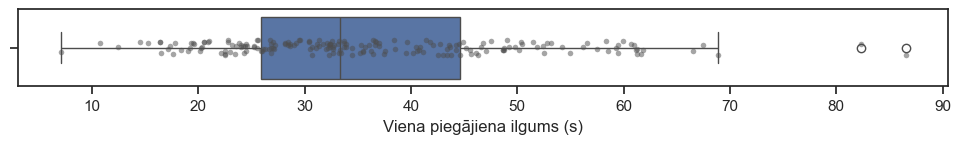

In [714]:
# exercise duration can be calculated from events_df start_watch and end_watch columns
events_df["duration"] = events_df["end_watch"] - events_df["start_watch"]
exercise_durations = events_df[["group", "duration"]].groupby("group").sum() / 1000 / 60
display(exercise_durations.style.format("{:.2f} minutes"))
total_exercise_duration = events_df["duration"].sum()
total_exercise_duration_min = total_exercise_duration / 1000 / 60
print(f"Total exercise duration (minutes): {total_exercise_duration_min:.2f}")

# average exercise duration of one set by group
average_exercise_duration = events_df[["group", "duration"]].groupby("group").mean() / 1000
display(average_exercise_duration.style.format("{:.2f} seconds"))
# overall average set duration
overall_average_duration = events_df["duration"].mean() / 1000
print(f"Overall average set duration: {overall_average_duration:.2f} seconds")

# plot boxplot of all exercise durations in seconds
def plot_exercise_durations(events_df):
    plt.figure(figsize=(12,1))
    sns.boxplot(x=events_df["duration"] / 1000)
    sns.stripplot(x=events_df["duration"] / 1000, size=4, color=".3", alpha=0.5)
    plt.xlabel("Viena piegājiena ilgums (s)")
    plt.show()

plot_exercise_durations(events_df)

In [715]:
# exercise/rest proportions
# format total duration hours so that it prints hours and minutes
def print_time(hours):
    h = int(hours)
    m = int((hours - h) * 60)
    return f"{h} hours and {m} minutes"
print(f"Total duration: {print_time(total_duration_hours)}")
print(f"Exercise duration: {total_exercise_duration_min:.2f} minutes")
# proportion of exercise duration to total duration
exercise_proportion = total_exercise_duration / total_duration
print(f"Exercise proportion: {exercise_proportion:.2%}")

# shortest and longest session
session_durations = [info["watch_end_timestamp"] - info["watch_start_timestamp"] for info in all_info]
shortest_session = min(session_durations) / 1000 / 60
longest_session = max(session_durations) / 1000 / 60
print(f"Shortest session: {print_time(shortest_session / 60)}")
print(f"Longest session: {print_time(longest_session / 60)}")
# average session duration
average_session_duration = np.mean(session_durations) / 1000 / 60
print(f"Average session duration: {print_time(average_session_duration / 60)}")

Total duration: 13 hours and 19 minutes
Exercise duration: 118.62 minutes
Exercise proportion: 14.84%
Shortest session: 0 hours and 37 minutes
Longest session: 2 hours and 9 minutes
Average session duration: 1 hours and 19 minutes


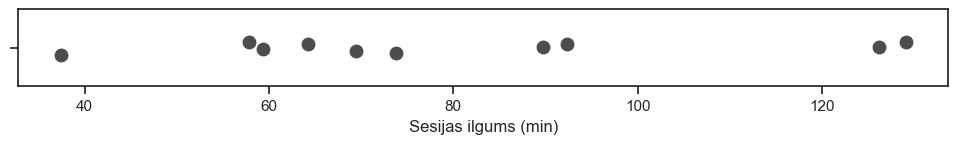

In [716]:
# boxplot of session durations in minutes
def plot_session_durations(all_info):
    session_durations = [(info["watch_end_timestamp"] - info["watch_start_timestamp"]) / 1000 / 60 for info in all_info]
    plt.figure(figsize=(12,1))
    sns.stripplot(x=session_durations, size=10, color=".3")
    plt.xlabel("Sesijas ilgums (min)")
    plt.show()
plot_session_durations(all_info)

In [717]:
events_df.columns

Index(['name', 'start_watch', 'end_watch', 'group', 'session', 'session_id',
       'duration'],
      dtype='str')

In [718]:
events_df.sort_values(by="duration", ascending=False)

,name,start_watch,end_watch,group,session,session_id,duration
62,Lat Pulldowns,1777027863751,1777027950310,Mugura,session_1777025558126,4,86559
176,Bulgarian Split Squat,1779629257877,1779629340193,Kājas,session_1779628611903,10,82316
68,Crunches,1777029342867,1777029411739,Vēders,session_1777025558126,4,68872
189,Assisted Pull-ups,1779632084620,1779632152066,Mugura,session_1779628611903,10,67446
178,Bulgarian Split Squat,1779629640121,1779629706601,Kājas,session_1779628611903,10,66480
...,...,...,...,...,...,...,...
81,Chest Press Machine,1777105483147,1777105498407,Krūtis,session_1777104300830,5,15260
80,Chest Press Machine,1777105374887,1777105389427,Krūtis,session_1777104300830,5,14540
96,Cable Rows,1777396222935,1777396235389,Mugura,session_1777394359098,6,12454
164,Tricep Pushdowns,1779610401636,1779610412408,Tricepsi,session_1779608056714,9,10772


In [719]:
# table of exercise group, name, count, total duration in minutes
exercise_summary = events_df.groupby(["group", "name"]).agg(
    count=("name", "count"),
    sessions=("session", "nunique"),
    total_duration=("duration", "sum")
).reset_index()

exercise_summary["total_duration"] = exercise_summary["total_duration"] / 1000 / 60
exercise_summary = exercise_summary.sort_values(by=["group", "name"], key=lambda x: x.map(lambda v: GROUP_ORDER.index(v) if v in GROUP_ORDER else 999))
exercise_summary.style.format(decimal=",", precision=2)

,group,name,count,sessions,total_duration
35,Vēders,Ab Crunch Machine,7,3,"3,77"
36,Vēders,Ab Roll Outs,1,1,"0,12"
37,Vēders,Cable Ab Crunches,2,1,"1,42"
38,Vēders,Crunches,6,4,"5,34"
39,Vēders,Leg Raises,6,3,"2,39"
40,Vēders,Plank,2,1,"1,58"
0,Bicepsi,Dumbbell Bicep Curls,8,3,"4,18"
1,Bicepsi,Hammer Curls,4,2,"2,25"
2,Bicepsi,Incline Dumbbell Curls,4,2,"3,36"
3,Bicepsi,Preacher Curls,7,3,"4,55"


In [720]:
def classification_report_per_session(
    df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    session_col="session_id",
):
    rows = []

    for session_id, session_df in df.groupby(session_col):
        y_true = session_df[truth_col].astype(int)
        y_pred = session_df[prediction_col].astype(int)

        report = classification_report(
            y_true,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        row = {
            "session_id": session_id,

            "accuracy": report["accuracy"],

            "precision_macro": report["macro avg"]["precision"],
            "precision_weighted": report["weighted avg"]["precision"],
            "precision_0": report["0"]["precision"],
            "precision_1": report["1"]["precision"],

            "recall_macro": report["macro avg"]["recall"],
            "recall_weighted": report["weighted avg"]["recall"],
            "recall_0": report["0"]["recall"],
            "recall_1": report["1"]["recall"],

            "f1_macro": report["macro avg"]["f1-score"],
            "f1_weighted": report["weighted avg"]["f1-score"],
            "f1_0": report["0"]["f1-score"],
            "f1_1": report["1"]["f1-score"],

            "support_0": report["0"]["support"],
            "support_1": report["1"]["support"],
        }

        rows.append(row)

    return pd.DataFrame(rows).sort_values("session_id").reset_index(drop=True)

In [721]:
print("Classification report:")
print(classification_report(
    windows_df["ground_truth"],
    windows_df["prediction_binary"],
    zero_division=0
))

print("Classification report (fine-tuned):")
print(classification_report(
    windows_df["ground_truth"],
    windows_df["prediction_finetuned_binary"],
    zero_division=0
))

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     39746
           1       0.57      0.63      0.60      7068

    accuracy                           0.87     46814
   macro avg       0.75      0.77      0.76     46814
weighted avg       0.88      0.87      0.87     46814

Classification report (fine-tuned):
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     39746
           1       0.72      0.82      0.77      7068

    accuracy                           0.92     46814
   macro avg       0.84      0.88      0.86     46814
weighted avg       0.93      0.92      0.93     46814



In [722]:
def classification_report_summary_table(df, truth_col="ground_truth", prediction_col="prediction_binary"):
    report = classification_report(df[truth_col], df[prediction_col], output_dict=True, zero_division=0)

    summary = {
        "accuracy": report["accuracy"],

        "precision_macro": report["macro avg"]["precision"],
        "precision_weighted": report["weighted avg"]["precision"],
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],

        "recall_macro": report["macro avg"]["recall"],
        "recall_weighted": report["weighted avg"]["recall"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],

        "f1_macro": report["macro avg"]["f1-score"],
        "f1_weighted": report["weighted avg"]["f1-score"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],

        "support_0": report["0"]["support"],
        "support_1": report["1"]["support"],
    }

    return pd.Series(summary)

# Classification report summary table

In [723]:
summary_original = classification_report_summary_table(windows_df)
summary_finetuned = classification_report_summary_table(
    windows_df,
    prediction_col="prediction_finetuned_binary"
)
summary_original_acc3 = classification_report_summary_table(
    df_acc_3,
    prediction_col="prediction_accumulator_3"
)
summary_finetuned_acc3 = classification_report_summary_table(
    df_acc_finetuned_3,
    prediction_col="prediction_finetuned_accumulator_3"
)
summary_finetuned_acc6 = classification_report_summary_table(
    df_acc_finetuned_6,
    prediction_col="prediction_finetuned_accumulator_6"
)
summary_inertia_1_10 = classification_report_summary_table(
    df_inertia,
    prediction_col="prediction_inertia_1_10"
)
summary_inertia_2_10 = classification_report_summary_table(
    df_inertia,
    prediction_col="prediction_inertia_2_10"
)

selected_metrics = ["precision_1", "recall_1", "f1_1", "f1_0", "f1_macro"]

summary_original = summary_original[selected_metrics]
summary_finetuned = summary_finetuned[selected_metrics]
summary_original_acc3 = summary_original_acc3[selected_metrics]
summary_finetuned_acc3 = summary_finetuned_acc3[selected_metrics]
summary_finetuned_acc6 = summary_finetuned_acc6[selected_metrics]
summary_inertia_1_10 = summary_inertia_1_10[selected_metrics]
summary_inertia_2_10 = summary_inertia_2_10[selected_metrics]

# Combine summaries as rows
summary_df = pd.DataFrame([summary_original, summary_finetuned, summary_original_acc3, summary_finetuned_acc3, summary_finetuned_acc6, summary_inertia_1_10, summary_inertia_2_10],
                          index=['Original', 'Finetuned', 'Original_Acc3', 'Finetuned_Acc3', 'Finetuned_Acc6', 'prediction_inertia_1_10', 'prediction_inertia_2_10'])

summary_df.style.format(decimal=",", precision=2).background_gradient(
    subset=selected_metrics,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1
)

,precision_1,recall_1,f1_1,f1_0,f1_macro
Original,"0,57","0,63","0,60","0,92","0,76"
Finetuned,"0,72","0,82","0,77","0,95","0,86"
Original_Acc3,"0,66","0,61","0,63","0,94","0,79"
Finetuned_Acc3,"0,76","0,81","0,78","0,96","0,87"
Finetuned_Acc6,"0,74","0,75","0,75","0,95","0,85"
prediction_inertia_1_10,"0,63","0,89","0,74","0,94","0,84"
prediction_inertia_2_10,"0,67","0,86","0,76","0,95","0,85"


## Per session

In [724]:
print("Classification report per session:")
session_report = classification_report_per_session(
    df=windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    session_col="session_id"
)

selected_metrics = ["precision_1", "recall_1", "f1_1", "f1_0", "f1_macro"]

session_report = session_report[["session_id"] + selected_metrics]

display(session_report.style.format(decimal=",", precision=2).background_gradient(
    subset=selected_metrics,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1
))

print("Classification report per session (fine-tuned):")
session_report = classification_report_per_session(
    df=windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_finetuned_binary",
    session_col="session_id"
)

session_report = session_report[["session_id"] + selected_metrics]

display(session_report.style.format(decimal=",", precision=2).background_gradient(
    subset=selected_metrics,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1
))

print("Classification report per session (finetuned accumulator 3):")

session_report = classification_report_per_session(
    df=df_acc_finetuned_3,
    truth_col="ground_truth",
    prediction_col="prediction_finetuned_accumulator_3",
    session_col="session_id"
)

session_report = session_report[["session_id"] + selected_metrics]
display(session_report.style.format(decimal=",", precision=2).background_gradient(
    subset=selected_metrics,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1
))

print("Classification report per session (inertia 1 10):")

session_report = classification_report_per_session(
    df=df_inertia,
    truth_col="ground_truth",
    prediction_col="prediction_inertia_1_10",
    session_col="session_id"
)

session_report = session_report[["session_id"] + selected_metrics]
display(session_report.style.format(decimal=",", precision=2).background_gradient(
    subset=selected_metrics,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1
))


Classification report per session:


,session_id,precision_1,recall_1,f1_1,f1_0,f1_macro
0,1,"0,64","0,76","0,69","0,93","0,81"
1,2,"0,48","0,81","0,60","0,93","0,77"
2,3,"0,68","0,55","0,61","0,91","0,76"
3,4,"0,49","0,43","0,46","0,89","0,67"
4,5,"0,75","0,44","0,56","0,92","0,74"
5,6,"0,61","0,62","0,61","0,93","0,77"
6,7,"0,41","0,65","0,50","0,95","0,72"
7,8,"0,56","0,56","0,56","0,93","0,74"
8,9,"0,60","0,62","0,61","0,93","0,77"
9,10,"0,63","0,74","0,68","0,91","0,79"


Classification report per session (fine-tuned):


,session_id,precision_1,recall_1,f1_1,f1_0,f1_macro
0,1,"0,76","0,81","0,78","0,96","0,87"
1,2,"0,71","0,97","0,82","0,97","0,89"
2,3,"0,85","0,94","0,89","0,97","0,93"
3,4,"0,70","0,85","0,77","0,94","0,86"
4,5,"0,89","0,69","0,78","0,95","0,87"
5,6,"0,75","0,75","0,75","0,95","0,85"
6,7,"0,74","0,75","0,74","0,98","0,86"
7,8,"0,61","0,82","0,70","0,94","0,82"
8,9,"0,69","0,86","0,76","0,95","0,86"
9,10,"0,64","0,77","0,70","0,91","0,81"


Classification report per session (finetuned accumulator 3):


,session_id,precision_1,recall_1,f1_1,f1_0,f1_macro
0,1,"0,77","0,78","0,77","0,96","0,87"
1,2,"0,74","0,96","0,84","0,98","0,91"
2,3,"0,86","0,93","0,90","0,97","0,93"
3,4,"0,71","0,84","0,77","0,95","0,86"
4,5,"0,92","0,67","0,78","0,95","0,87"
5,6,"0,77","0,72","0,74","0,95","0,85"
6,7,"0,84","0,72","0,78","0,98","0,88"
7,8,"0,70","0,85","0,77","0,96","0,86"
8,9,"0,74","0,85","0,79","0,96","0,88"
9,10,"0,70","0,79","0,74","0,93","0,83"


Classification report per session (inertia 1 10):


,session_id,precision_1,recall_1,f1_1,f1_0,f1_macro
0,1,"0,67","0,86","0,76","0,95","0,85"
1,2,"0,62","0,99","0,76","0,96","0,86"
2,3,"0,74","0,98","0,85","0,95","0,90"
3,4,"0,61","0,91","0,73","0,92","0,82"
4,5,"0,81","0,83","0,82","0,96","0,89"
5,6,"0,67","0,81","0,73","0,95","0,84"
6,7,"0,66","0,82","0,73","0,97","0,85"
7,8,"0,54","0,93","0,68","0,92","0,80"
8,9,"0,57","0,91","0,70","0,93","0,81"
9,10,"0,57","0,87","0,69","0,89","0,79"


# Group coverage

## Methods

In [725]:
def calculate_group_coverage(
    df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    group_col="ground_truth_group"
):
    exercise_windows = df[df[truth_col] == 1].copy()

    coverage = (
        exercise_windows
        .groupby(group_col)
        .agg(
            total_exercise_windows=(truth_col, "count"),
            predicted_exercise_windows=(prediction_col, "sum")
        )
        .reset_index()
    )

    coverage["coverage"] = (
        coverage["predicted_exercise_windows"] /
        coverage["total_exercise_windows"]
    )

    coverage["coverage_percent"] = coverage["coverage"] * 100

    return coverage.sort_values("coverage_percent", ascending=False)

In [726]:
def calculate_activity_coverage(
    df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    activity_col="ground_truth_activity"
):
    exercise_windows = df[df[truth_col] == 1].copy()

    coverage = (
        exercise_windows
        .groupby([activity_col, "ground_truth_group"])
        .agg(
            total_exercise_windows=(truth_col, "count"),
            predicted_exercise_windows=(prediction_col, "sum")
        )
        .reset_index()
    )

    coverage["coverage"] = (
        coverage["predicted_exercise_windows"] /
        coverage["total_exercise_windows"]
    )

    coverage["coverage_percent"] = coverage["coverage"] * 100

    return coverage.sort_values("coverage_percent", ascending=False)

In [727]:
def plot_group_coverage(
    group_coverage_df,
    group_col="ground_truth_group",
    coverage_col="coverage_percent",
    title="Muskuļu grupu kopējais pārklājums",
    xlabel="Pārklājums (%)",
    ylabel="Muskuļu grupa",
    xlim=(0, 100)
):
    plot_df = group_coverage_df.sort_values(coverage_col, ascending=False).copy()

    f, ax = plt.subplots(figsize=(8, 4))

    sns.barplot(
        data=plot_df,
        x=coverage_col,
        y=group_col,
        color="skyblue",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)

    ax.set_xlim(*xlim)
    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title
    )

    ax.xaxis.grid(True)
    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [728]:
def compare_group_coverage(
    df,
    truth_col="ground_truth",
    base_prediction_col="prediction_binary",
    finetuned_prediction_col="prediction_finetuned_binary",
    group_col="ground_truth_group"
):
    base = calculate_group_coverage(
        df=df,
        truth_col=truth_col,
        prediction_col=base_prediction_col,
        group_col=group_col
    )
    base["Modelis"] = "Sākotnējais"

    finetuned = calculate_group_coverage(
        df=df,
        truth_col=truth_col,
        prediction_col=finetuned_prediction_col,
        group_col=group_col
    )
    finetuned["Modelis"] = "Pielāgotais"

    return pd.concat([base, finetuned], ignore_index=True)

In [729]:
def plot_group_coverage_comparison(
    group_coverage_comparison,
    group_col="ground_truth_group",
    coverage_col="coverage_percent",
    model_col="Modelis",
    title="Muskuļu grupu pārklājuma salīdzinājums",
    xlabel="Pārklājums (%)",
    ylabel="Muskuļu grupa",
    xlim=(0, 100),
    group_order=None,
    model_order=["Sākotnējais", "Pielāgotais"]
):
    plot_df = group_coverage_comparison.copy()

    if group_order is not None:
        plot_df[group_col] = pd.Categorical(
            plot_df[group_col],
            categories=group_order,
            ordered=True
        )
    else:
        order_df = (
            plot_df[plot_df[model_col] == "Pielāgotais"]
            .sort_values(coverage_col, ascending=False)
        )
        group_order = order_df[group_col].tolist()

        plot_df[group_col] = pd.Categorical(
            plot_df[group_col],
            categories=group_order,
            ordered=True
        )

    plot_df = plot_df.sort_values(group_col)

    f, ax = plt.subplots(figsize=(9, 2 * len(model_order)))

    sns.barplot(
        data=plot_df,
        x=coverage_col,
        y=group_col,
        hue=model_col,
        hue_order=model_order,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)

    ax.set_xlim(*xlim)
    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title
    )

    ax.xaxis.grid(True)
    ax.legend(title="Modelis")

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [730]:
def calculate_group_session_coverage(
    df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    session_col="session_id",
    group_col="ground_truth_group"
):
    exercise_df = df[df[truth_col] == 1].copy()

    coverage_df = (
        exercise_df
        .groupby([group_col, session_col])
        .agg(
            total_exercise_windows=(truth_col, "count"),
            predicted_exercise_windows=(prediction_col, "sum")
        )
        .reset_index()
    )

    coverage_df["coverage"] = (
        coverage_df["predicted_exercise_windows"] /
        coverage_df["total_exercise_windows"]
    )

    coverage_df["coverage_percent"] = coverage_df["coverage"] * 100

    return coverage_df

In [731]:
def make_group_session_coverage_pivot(
    coverage_df,
    group_col="ground_truth_group",
    session_col="session_id",
    value_col="coverage_percent",
    group_order=None,
    session_order=None
):
    pivot_df = coverage_df.pivot(
        index=group_col,
        columns=session_col,
        values=value_col
    )

    if group_order is not None:
        pivot_df = pivot_df.reindex(group_order)

    if session_order is not None:
        pivot_df = pivot_df[session_order]

    return pivot_df

In [732]:
def plot_group_session_coverage_heatmap(
    coverage_pivot,
    title="Muskuļu grupu pārklājums pa sesijām",
    xlabel="Sesija",
    ylabel=None,
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    center=None,
    annot=True,
    fmt=".1f"
):
    plt.figure(figsize=(9, 5))

    ax = sns.heatmap(
        coverage_pivot,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Pārklājums (%)"}
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [733]:
def plot_group_session_coverage_heatmaps_side_by_side(
    coverage_pivot_left,
    coverage_pivot_right,
    title_left="Sākotnējais modelis",
    title_right="Pielāgotais modelis",
    main_title="Muskuļu grupu pārklājums pa sesijām",
    xlabel="Sesija",
    ylabel="Muskuļu grupa",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    center=None,
    annot=True,
    fmt=".1f",
    figsize=(14, 5)
):
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=figsize,
        sharey=True,
        constrained_layout=True
    )

    # One shared colorbar axis
    cbar_ax = fig.add_axes([1.01, 0.18, 0.015, 0.65])

    sns.heatmap(
        coverage_pivot_left,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        cbar=False,
        ax=axes[0]
    )

    sns.heatmap(
        coverage_pivot_right,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={"label": "Pārklājums (%)"},
        ax=axes[1]
    )

    axes[0].set_title(title_left)
    axes[1].set_title(title_right)

    axes[0].set_xlabel(xlabel)
    axes[1].set_xlabel(xlabel)

    axes[0].set_ylabel(ylabel)
    axes[1].set_ylabel(None)

    fig.suptitle(main_title, fontsize=14)

    plt.show()

## stats

In [734]:
group_coverage = calculate_group_coverage(
    df=windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    group_col="ground_truth_group"
)

display(group_coverage.style.format(decimal=",", precision=2))

group_coverage_finetuned = calculate_group_coverage(
    df=windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_finetuned_binary",
    group_col="ground_truth_group"
)

display(group_coverage_finetuned.style.format(decimal=",", precision=2))

group_coverage_acc3 = calculate_group_coverage(
    df=df_acc_3,
    truth_col="ground_truth",
    prediction_col="prediction_accumulator_3",
    group_col="ground_truth_group"
)

group_coverage_finetuned_acc3 = calculate_group_coverage(
    df=df_acc_finetuned_3,
    truth_col="ground_truth",
    prediction_col="prediction_finetuned_accumulator_3",
    group_col="ground_truth_group"
)

group_coverage_inertia_1_10 = calculate_group_coverage(
    df=df_inertia,
    truth_col="ground_truth",
    prediction_col="prediction_inertia_1_10",
    group_col="ground_truth_group"
)

group_coverage_inertia_2_10 = calculate_group_coverage(
    df=df_inertia,
    truth_col="ground_truth",
    prediction_col="prediction_inertia_2_10",
    group_col="ground_truth_group"
)

,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent
0,Bicepsi,853,720,"0,84","84,41"
2,Kājas,1847,1524,"0,83","82,51"
5,Tricepsi,801,594,"0,74","74,16"
6,Vēders,873,543,"0,62","62,20"
1,Krūtis,997,405,"0,41","40,62"
3,Mugura,994,387,"0,39","38,93"
4,Pleci,703,256,"0,36","36,42"


,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent
0,Bicepsi,853,788,"0,92","92,38"
3,Mugura,994,877,"0,88","88,23"
5,Tricepsi,801,706,"0,88","88,14"
2,Kājas,1847,1525,"0,83","82,57"
1,Krūtis,997,820,"0,82","82,25"
4,Pleci,703,536,"0,76","76,24"
6,Vēders,873,536,"0,61","61,40"


In [735]:
group_coverage_comparison = compare_group_coverage(
    windows_df,
    truth_col="ground_truth",
    base_prediction_col="prediction_binary",
    finetuned_prediction_col="prediction_finetuned_binary",
    group_col="ground_truth_group"
)

group_coverage_acc3["Modelis"] = "Sākotnējais (Acc3)"
group_coverage_finetuned_acc3["Modelis"] = "Pielāgotais (Acc3)"
group_coverage_inertia_1_10["Modelis"] = "Inertia 1 10"
group_coverage_inertia_2_10["Modelis"] = "Inertia 2 10"


group_coverage_comparison = pd.concat(
    [group_coverage_comparison, group_coverage_acc3, group_coverage_finetuned_acc3,
     group_coverage_inertia_1_10, group_coverage_inertia_2_10],
    ignore_index=True
)

#display(group_coverage_comparison.style.format(decimal=",", precision=2))

## plots

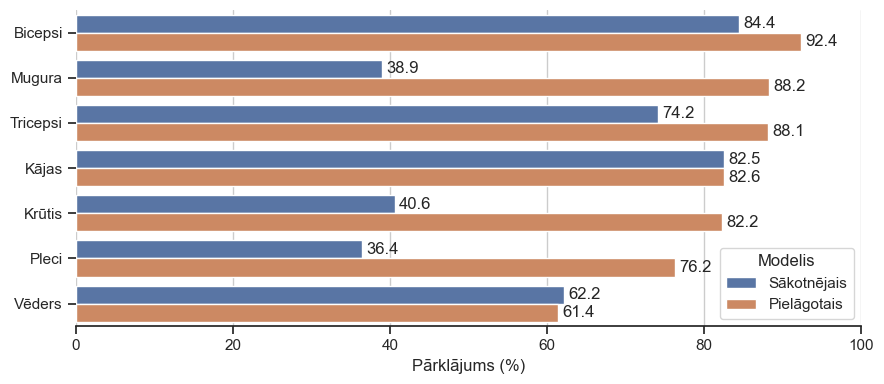

In [833]:
plot_group_coverage_comparison(
    group_coverage_comparison,
    title="",
    ylabel="",
    model_order=["Sākotnējais", "Pielāgotais"],
)

In [737]:
group_session_coverage = calculate_group_session_coverage(
    windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    session_col="session_id",
    group_col="ground_truth_group"
)

display(group_session_coverage.head(10).style.format(decimal=",", precision=2))

group_session_coverage_finetuned = calculate_group_session_coverage(
    windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_finetuned_binary",
    session_col="session_id",
    group_col="ground_truth_group"
)

group_session_coverage_finetuned_acc3 = calculate_group_session_coverage(
    df=df_acc_finetuned_3,
    prediction_col="prediction_finetuned_accumulator_3"
)

,ground_truth_group,session_id,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent
0,Bicepsi,1,73,57,"0,78","78,08"
1,Bicepsi,2,75,63,"0,84","84,00"
2,Bicepsi,3,104,86,"0,83","82,69"
3,Bicepsi,4,61,58,"0,95","95,08"
4,Bicepsi,5,48,39,"0,81","81,25"
5,Bicepsi,6,156,144,"0,92","92,31"
6,Bicepsi,7,97,66,"0,68","68,04"
7,Bicepsi,8,60,40,"0,67","66,67"
8,Bicepsi,9,65,63,"0,97","96,92"
9,Bicepsi,10,114,104,"0,91","91,23"


In [738]:
coverage_pivot = make_group_session_coverage_pivot(
    group_session_coverage,
    group_order=GROUP_ORDER
)

coverage_pivot_finetuned = make_group_session_coverage_pivot(
    group_session_coverage_finetuned,
    group_order=GROUP_ORDER
)

coverage_pivot_finetuned_acc3 = make_group_session_coverage_pivot(
    group_session_coverage_finetuned_acc3,
    group_order=GROUP_ORDER
)

display(coverage_pivot.style.format(decimal=",", precision=1))

session_id,1,2,3,4,5,6,7,8,9,10
ground_truth_group,,,,,,,,,,
Vēders,"70,7","67,3","95,9","32,5","45,9","52,6","54,7","64,3","98,0","65,2"
Bicepsi,"78,1","84,0","82,7","95,1","81,2","92,3","68,0","66,7","96,9","91,2"
Tricepsi,"94,8","84,6","91,9","83,8","25,0","72,3","17,5","15,3","90,7","92,1"
Mugura,"3,9","85,6","2,7","23,5","59,8","50,7","49,3","38,5","15,2","37,3"
Krūtis,"78,4","81,3","1,9","11,9","10,7","32,9","80,0","86,0","10,3","57,7"
Kājas,"96,8","94,4","87,0","64,1","70,0","91,7","98,8","68,2","69,9","77,5"
Pleci,"92,1","38,1","2,0","5,1","5,9","39,8","0,0","45,2","58,5","83,6"


## Heatmap

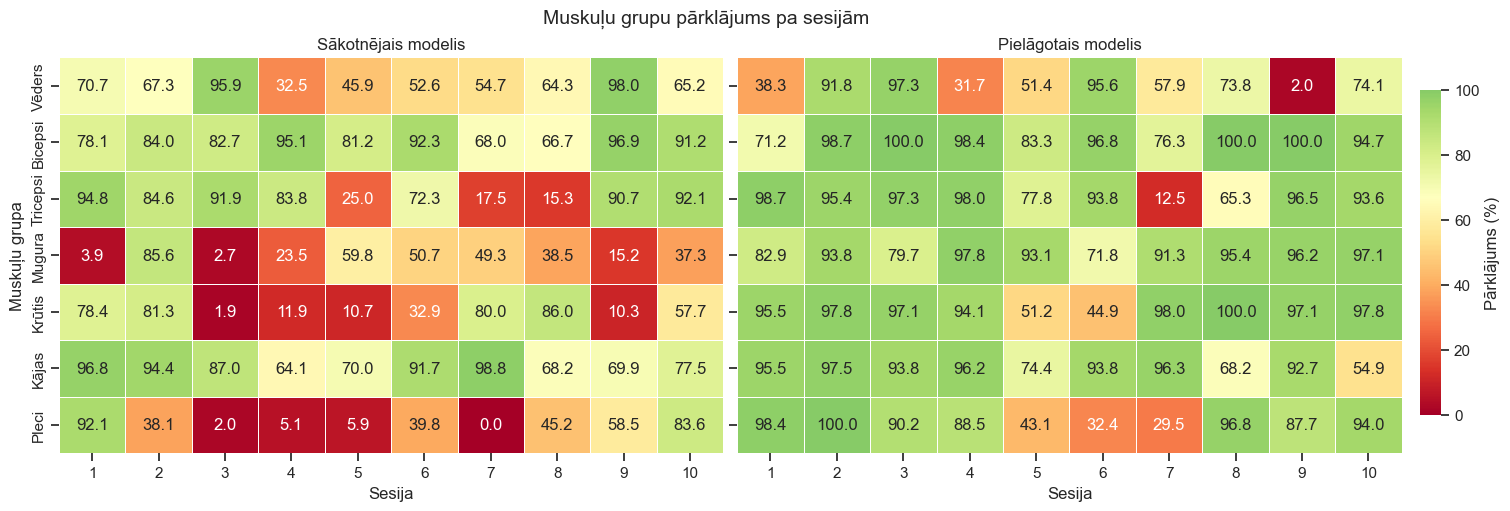

In [739]:
plot_group_session_coverage_heatmaps_side_by_side(
    coverage_pivot,
    coverage_pivot_finetuned,
    title_left="Sākotnējais modelis",
    title_right="Pielāgotais modelis",
    main_title="Muskuļu grupu pārklājums pa sesijām",
    figsize=(14, 5),
    center=67
)

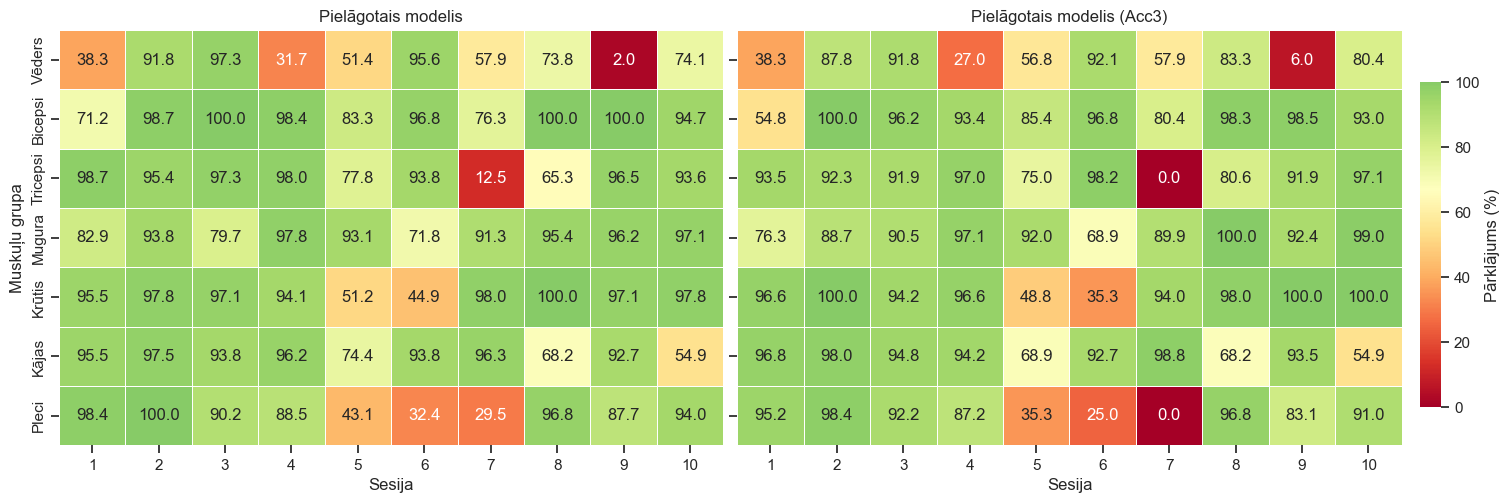

In [740]:
plot_group_session_coverage_heatmaps_side_by_side(
    coverage_pivot_finetuned,
    coverage_pivot_finetuned_acc3,
    title_left="Pielāgotais modelis",
    title_right="Pielāgotais modelis (Acc3)",
    main_title="",
    figsize=(14, 5),
    center=67
)

## per exercise

In [741]:
def plot_activity_coverage_comparison(
    activity_coverage_comparison,
    group_col="ground_truth_activity",
    activity_group_col="ground_truth_group",
    selected_group=None,
    coverage_col="coverage_percent",
    model_col="Modelis",
    title="Vingrinājumu pārklājuma salīdzinājums",
    xlabel="Pārklājums (%)",
    ylabel="Vingrinājums",
    xlim=(0, 100),
    group_order=None,
    model_order=["Sākotnējais", "Pielāgotais"],
    figsize=(16, 12)
):
    plot_df = activity_coverage_comparison.copy()

    if selected_group is not None:
        plot_df = plot_df[plot_df[activity_group_col] == selected_group].copy()

        if title == "Vingrinājumu pārklājuma salīdzinājums":
            title = f"{selected_group} vingrinājumu pārklājuma salīdzinājums"

    if plot_df.empty:
        print(f"No data to plot for group: {selected_group}")
        return

    if group_order is not None:
        plot_df[group_col] = pd.Categorical(
            plot_df[group_col],
            categories=group_order,
            ordered=True
        )
    else:
        order_df = (
            plot_df[plot_df[model_col] == model_order[-1]]
            .sort_values(coverage_col, ascending=False)
        )

        group_order = order_df[group_col].dropna().unique().tolist()

        plot_df[group_col] = pd.Categorical(
            plot_df[group_col],
            categories=group_order,
            ordered=True
        )

    plot_df = plot_df.sort_values(group_col)

    f, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=plot_df,
        x=coverage_col,
        y=group_col,
        hue=model_col,
        hue_order=model_order,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)

    ax.set_xlim(*xlim)
    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title
    )

    ax.xaxis.grid(True)
    ax.legend(title="Modelis")

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [742]:
activity_coverage = calculate_activity_coverage(
    df=windows_df
)

display(activity_coverage.style.format(decimal=",", precision=2))

activity_coverage_finetuned = calculate_activity_coverage(
    df=windows_df,
    prediction_col="prediction_finetuned_binary"
)

activity_coverage_finetuned_acc3 = calculate_activity_coverage(
    df=df_acc_finetuned_3,
    prediction_col="prediction_finetuned_accumulator_3",
)

,ground_truth_activity,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent
37,Single Leg Romanian Deadlifts,Kājas,115,113,"0,98","98,26"
35,Romanian Deadlifts,Kājas,180,175,"0,97","97,22"
38,Stiff-Leg Deadlifts,Kājas,228,216,"0,95","94,74"
23,Goblet Squats,Kājas,313,288,"0,92","92,01"
16,Deadlifts,Kājas,62,57,"0,92","91,94"
33,Preacher Curls,Bicepsi,269,246,"0,91","91,45"
19,Dumbbell Bicep Curls,Bicepsi,248,219,"0,88","88,31"
30,Machine Deadlifts,Kājas,124,109,"0,88","87,90"
40,Tricep Pushdowns,Tricepsi,577,495,"0,86","85,79"
39,Straight Arm Lat Pulldowns,Mugura,97,83,"0,86","85,57"


In [743]:


activity_coverage["Modelis"] = "Sākotnējais"
activity_coverage_finetuned["Modelis"] = "Pielāgotais"
activity_coverage_finetuned_acc3["Modelis"] = "Pielāgotais ar slieksni 3"


activity_coverage_comparison = pd.concat(
    [activity_coverage, activity_coverage_finetuned, activity_coverage_finetuned_acc3],
    ignore_index=True
)

#display(group_coverage_comparison.style.format(decimal=",", precision=2))



In [744]:
activity_coverage_comparison["ground_truth_group"].unique()

<StringArray>
['Kājas', 'Bicepsi', 'Tricepsi', 'Mugura', 'Krūtis', 'Vēders', 'Pleci']
Length: 7, dtype: str

In [836]:
activity_coverage_comparison

,ground_truth_activity,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent,Modelis
0,Single Leg Romanian Deadlifts,Kājas,115,113,0.982609,98.260870,Sākotnējais
1,Romanian Deadlifts,Kājas,180,175,0.972222,97.222222,Sākotnējais
2,Stiff-Leg Deadlifts,Kājas,228,216,0.947368,94.736842,Sākotnējais
3,Goblet Squats,Kājas,313,288,0.920128,92.012780,Sākotnējais
4,Deadlifts,Kājas,62,57,0.919355,91.935484,Sākotnējais
...,...,...,...,...,...,...,...
118,Cable Lateral Raises,Pleci,108,27,0.250000,25.000000,Pielāgotais ar slieksni 3
119,Plank,Vēders,95,16,0.168421,16.842105,Pielāgotais ar slieksni 3
120,Cable Chest Fly,Krūtis,134,5,0.037313,3.731343,Pielāgotais ar slieksni 3
121,Dips,Tricepsi,40,0,0.000000,0.000000,Pielāgotais ar slieksni 3


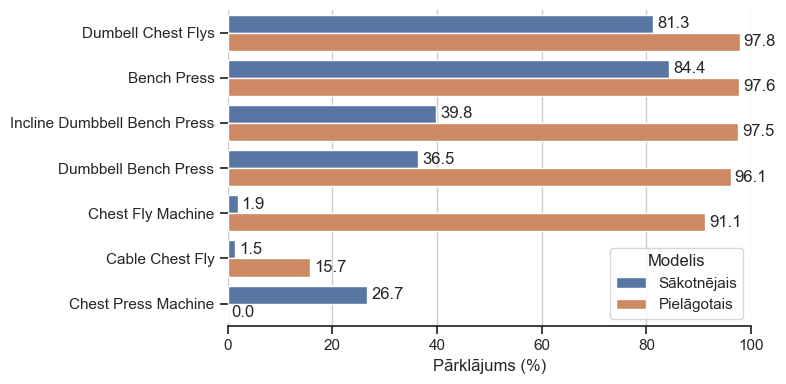

In [834]:
plot_activity_coverage_comparison(
    activity_coverage_comparison,
    selected_group="Krūtis",
    title="",
    ylabel="",
    model_order=[
        "Sākotnējais",
        "Pielāgotais"
    ],
    group_col="ground_truth_activity",
    activity_group_col="ground_truth_group",
    figsize=(8, 4)
)

In [746]:
def plot_activity_coverage_comparison_grouped(
    activity_coverage_comparison,
    activity_col="ground_truth_activity",
    activity_group_col="ground_truth_group",
    coverage_col="coverage_percent",
    model_col="Modelis",
    model_order=None,
    group_order=None,
    selected_group=None,
    title="Vingrinājumu pārklājuma salīdzinājums pa muskuļu grupām",
    xlabel="Pārklājums (%)",
    ylabel="Vingrinājums",
    xlim=(0, 115),
    figsize=None
):
    plot_df = activity_coverage_comparison.copy()

    if selected_group is not None:
        plot_df = plot_df[
            plot_df[activity_group_col] == selected_group
        ].copy()

    if plot_df.empty:
        print("No data to plot.")
        return

    if model_order is None:
        model_order = plot_df[model_col].dropna().unique().tolist()

    if group_order is None:
        group_order = plot_df[activity_group_col].dropna().unique().tolist()

    # Use the last model in model_order for sorting exercises inside each group
    sort_model = model_order[-1]

    order_df = (
        plot_df[plot_df[model_col] == sort_model]
        [[activity_group_col, activity_col, coverage_col]]
        .copy()
    )

    order_df["group_order"] = order_df[activity_group_col].map(
        lambda g: group_order.index(g) if g in group_order else 999
    )

    order_df = order_df.sort_values(
        ["group_order", coverage_col],
        ascending=[True, False]
    )

    activity_order = order_df[activity_col].tolist()

    plot_df[activity_col] = pd.Categorical(
        plot_df[activity_col],
        categories=activity_order,
        ordered=True
    )

    plot_df = plot_df.sort_values(activity_col).reset_index(drop=True)

    if figsize is None:
        figsize = (12, max(8, len(activity_order) * 0.45))

    f, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=plot_df,
        x=coverage_col,
        y=activity_col,
        hue=model_col,
        hue_order=model_order,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f",
            padding=3,
            fontsize=8
        )

    # One row per exercise for separator positions
    exercise_group_df = (
        plot_df[[activity_col, activity_group_col]]
        .drop_duplicates()
        .sort_values(activity_col)
        .reset_index(drop=True)
    )

    group_change_indices = (
        exercise_group_df[activity_group_col] !=
        exercise_group_df[activity_group_col].shift()
    )

    group_start_indices = exercise_group_df.index[group_change_indices].tolist()

    for idx in group_start_indices[1:]:
        ax.axhline(
            idx - 0.5,
            color="black",
            linewidth=1,
            alpha=0.35
        )

    # Add group names on the right
    for group, group_df in exercise_group_df.groupby(activity_group_col, sort=False):
        middle = (group_df.index.min() + group_df.index.max()) / 2

        ax.text(
            xlim[1] - 8,
            middle,
            group,
            va="center",
            ha="left",
            fontweight="bold",
            fontsize=11
        )

    ax.set_xlim(*xlim)

    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title
    )

    ax.xaxis.grid(True)
    ax.legend(title="Modelis", loc="lower right")

    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

    return plot_df

In [747]:
activity_coverage_comparison

,ground_truth_activity,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent,Modelis
0,Single Leg Romanian Deadlifts,Kājas,115,113,0.982609,98.260870,Sākotnējais
1,Romanian Deadlifts,Kājas,180,175,0.972222,97.222222,Sākotnējais
2,Stiff-Leg Deadlifts,Kājas,228,216,0.947368,94.736842,Sākotnējais
3,Goblet Squats,Kājas,313,288,0.920128,92.012780,Sākotnējais
4,Deadlifts,Kājas,62,57,0.919355,91.935484,Sākotnējais
...,...,...,...,...,...,...,...
118,Cable Lateral Raises,Pleci,108,27,0.250000,25.000000,Pielāgotais ar slieksni 3
119,Plank,Vēders,95,16,0.168421,16.842105,Pielāgotais ar slieksni 3
120,Cable Chest Fly,Krūtis,134,5,0.037313,3.731343,Pielāgotais ar slieksni 3
121,Dips,Tricepsi,40,0,0.000000,0.000000,Pielāgotais ar slieksni 3


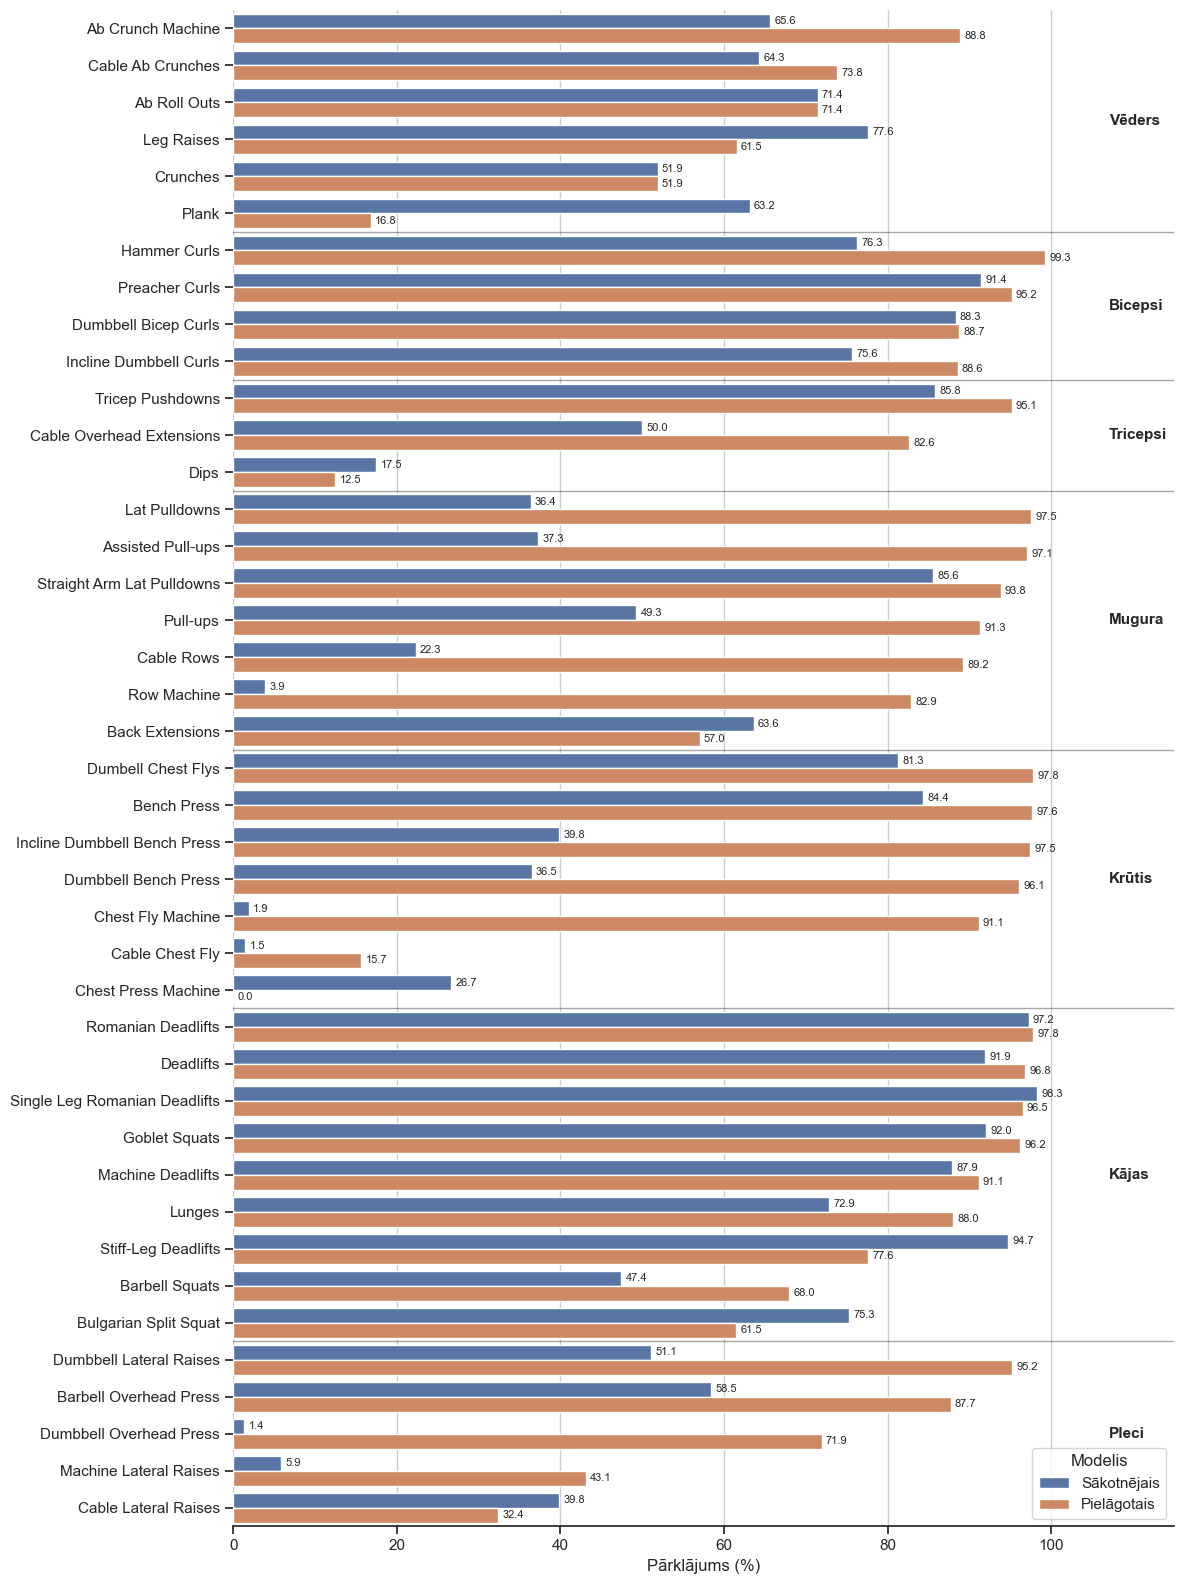

In [748]:
plot_df = plot_activity_coverage_comparison_grouped(
    activity_coverage_comparison,
    activity_col="ground_truth_activity",
    activity_group_col="ground_truth_group",
    model_order=[
        "Sākotnējais",
        "Pielāgotais"
    ],
    group_order=GROUP_ORDER,
    title="",
    ylabel="",
    figsize=(12, 16)
)

In [749]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(plot_df[plot_df["Modelis"] == "Pielāgotais"].style.format(decimal=",", precision=2))

,ground_truth_activity,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent,Modelis
0,Ab Crunch Machine,Vēders,224,199,"0,89","88,84",Pielāgotais
4,Cable Ab Crunches,Vēders,84,62,"0,74","73,81",Pielāgotais
8,Ab Roll Outs,Vēders,7,5,"0,71","71,43",Pielāgotais
9,Leg Raises,Vēders,143,88,"0,62","61,54",Pielāgotais
14,Crunches,Vēders,320,166,"0,52","51,88",Pielāgotais
17,Plank,Vēders,95,16,"0,17","16,84",Pielāgotais
19,Hammer Curls,Bicepsi,135,134,"0,99","99,26",Pielāgotais
21,Preacher Curls,Bicepsi,269,256,"0,95","95,17",Pielāgotais
24,Dumbbell Bicep Curls,Bicepsi,248,220,"0,89","88,71",Pielāgotais
28,Incline Dumbbell Curls,Bicepsi,201,178,"0,89","88,56",Pielāgotais


In [750]:
def exercise_appearance_and_coverage_comparison_table(
    coverage_dfs,
    model_names,
    latency_df,
    activity_col="ground_truth_activity",
    latency_activity_col="name",
    group_col="ground_truth_group",
    coverage_col="coverage_percent"
):
    # Base table: exercise group + exercise name from first coverage df
    base = coverage_dfs[0][[group_col, activity_col]].drop_duplicates().copy()

    # Add appearance count from annotated segments
    appearance_counts = (
        latency_df
        .groupby(latency_activity_col, dropna=False)
        .size()
        .reset_index(name="Piegājienu skaits")
        .rename(columns={latency_activity_col: activity_col})
    )

    table = base.merge(
        appearance_counts,
        on=activity_col,
        how="left"
    )

    table["Piegājienu skaits"] = table["Piegājienu skaits"].fillna(0).astype(int)

    # Add coverage for each model
    for coverage_df, model_name in zip(coverage_dfs, model_names):
        model_coverage = coverage_df[[activity_col, coverage_col]].copy()
        model_coverage = model_coverage.rename(columns={
            coverage_col: f"Pārklājums (%) - {model_name}"
        })

        table = table.merge(
            model_coverage,
            on=activity_col,
            how="left"
        )

    table = table.rename(columns={
        group_col: "Grupa",
        activity_col: "Vingrinājums"
    })

    coverage_columns = [
        f"Pārklājums (%) - {model_name}"
        for model_name in model_names
    ]

    return table[
        ["Grupa", "Vingrinājums", "Piegājienu skaits"] + coverage_columns
    ].sort_values(["Grupa", "Vingrinājums"])

In [751]:
# exercise_coverage_table = exercise_appearance_and_coverage_comparison_table(
#     coverage_dfs=[
#         activity_coverage,
#         activity_coverage_finetuned,
#         activity_coverage_finetuned_acc3
#     ],
#     model_names=[
#         "Sākotnējais",
#         "Pielāgotais",
#     ],
#     latency_df=latency_df,
#     activity_col="ground_truth_activity",
#     latency_activity_col="name",
#     group_col="ground_truth_group",
#     coverage_col="coverage_percent"
# )

# display(exercise_coverage_table.sort_values("Piegājienu skaits").style.format(decimal=",", precision=2))

# Fragmentation

## Methods

### Plot Methods

In [752]:
def plot_fragmentation_distribution(fragmentation_df):
    f, ax = plt.subplots(figsize=(7, 4))

    sns.countplot(
        data=fragmentation_df,
        x="fragment_count",
        color="skyblue"
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Segmentu skaits",
        #title="Vingrošanas segmentu fragmentācija"
    )

    ax.xaxis.grid(True)

    sns.despine()

    plt.show()


def plot_fragmentation_distribution_comparison(
    fragmentation_dfs,
    model_order=["Sākotnējais", "Pielāgotais"]
):
    combined_df = pd.concat(fragmentation_dfs, ignore_index=True)
    

    f, ax = plt.subplots(figsize=(9, 4))

    sns.histplot(
        data=combined_df,
        x="fragment_count",
        hue="Modelis",
        hue_order=model_order,
        discrete=True,
        stat="percent",
        multiple="dodge",
        shrink=0.8,
        common_norm=False,
        ax=ax
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Segmentu īpatsvars (%)"
    )

    max_fragments = int(combined_df["fragment_count"].max())
    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_fragmentation_per_exercise(fragmentation_df):
    df = fragmentation_df.copy()

    # ordered categorical group
    df["group"] = pd.Categorical(
        df["group"],
        categories=GROUP_ORDER,
        ordered=True
    )

    # exercise order grouped by muscle group
    exercise_order = (
        df[["group", "name"]]
        .drop_duplicates()
        .sort_values(["group", "name"])
    )["name"].tolist()

    f, ax = plt.subplots(
        figsize=(9, max(3, len(exercise_order) * 0.35))
    )

    sns.boxplot(
        data=df,
        x="fragment_count",
        y="name",
        order=exercise_order,
        color="skyblue",
        whis=[0, 100],
        ax=ax
    )

    sns.stripplot(
        data=df,
        x="fragment_count",
        y="name",
        order=exercise_order,
        size=4,
        color=".3",
        alpha=0.5,
        ax=ax
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Vingrinājums"
    )

    max_fragments = df["fragment_count"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    # ---- Add group labels and separators ----

    group_positions = []

    current_y = 0

    for group in GROUP_ORDER:
        exercises = [
            ex for ex in exercise_order
            if EXERCISE_GROUPS.get(ex) == group
        ]

        if not exercises:
            continue

        start_y = current_y
        end_y = current_y + len(exercises) - 1
        middle_y = (start_y + end_y) / 2

        group_positions.append((group, middle_y))

        # separator line
        if start_y != 0:
            ax.axhline(
                start_y - 0.5,
                color="lightgray",
                linewidth=1
            )

        current_y += len(exercises)

    # right-side group labels
    xmax = ax.get_xlim()[1]

    for group, y in group_positions:
        ax.text(
            xmax + 0.2,
            y,
            group,
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    sns.despine(trim=True, left=True)

    plt.tight_layout()
    plt.show()

def plot_fragmentation_per_session(fragmentation_df):
    f, ax = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=fragmentation_df,
        x="fragment_count",
        y=fragmentation_df["session_id"].astype(str),
        whis=[0, 100],
        color="skyblue"
    )

    sns.stripplot(
        data=fragmentation_df,
        x="fragment_count",
        y=fragmentation_df["session_id"].astype(str),
        color=".3",
        alpha=0.5,
        size=4
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Sesija",
        #title="Vingrošanas segmentu fragmentācija pa sesijām"
    )

    max_fragments = fragmentation_df["fragment_count"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    sns.despine(trim=True)

    plt.show()

def plot_fragmentation_per_session_comparison(fragmentation_dfs):

    combined_df = pd.concat(fragmentation_dfs, ignore_index=True)
    combined_df["session_id"] = combined_df["session_id"].astype(str)

    f, ax = plt.subplots(figsize=(9, 4))

    sns.boxplot(
        data=combined_df,
        x="fragment_count",
        y="session_id",
        hue="Modelis",
        whis=[0, 100],
        dodge=True
    )

    sns.stripplot(
        data=combined_df,
        x="fragment_count",
        y="session_id",
        hue="Modelis",
        dodge=True,
        palette="dark:.3",
        alpha=0.45,
        size=4
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Sesija"
    )

    max_fragments = combined_df["fragment_count"].max()
    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    # Remove duplicate legends caused by boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:3],
        labels[:3],
        title="Modelis",
        loc="best"
    )

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

def plot_fragmentation_per_group(fragmentation_df):
    f, ax = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=fragmentation_df,
        x="fragment_count",
        y="group",
        whis=[0, 100],
        color="skyblue"
    )

    sns.stripplot(
        data=fragmentation_df,
        x="fragment_count",
        y="group",
        color=".3",
        alpha=0.5,
        size=4
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Muskuļu grupa",
    )

    max_fragments = fragmentation_df["fragment_count"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    sns.despine(trim=True)

    plt.show()

def plot_fragmentation_per_group_comparison(fragmentation_dfs):
    combined_df = pd.concat(fragmentation_dfs, ignore_index=True)

    f, ax = plt.subplots(figsize=(9, 4))

    sns.boxplot(
        data=combined_df,
        x="fragment_count",
        y="group",
        hue="Modelis",
        whis=[0, 100],
        dodge=True,
        ax=ax
    )

    sns.stripplot(
        data=combined_df,
        x="fragment_count",
        y="group",
        hue="Modelis",
        dodge=True,
        palette="dark:.3",
        alpha=0.45,
        size=4,
        ax=ax
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Muskuļu grupa"
    )

    max_fragments = int(combined_df["fragment_count"].max())
    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    # Remove duplicate legends from boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:2],
        labels[:2],
        title="Modelis",
        loc="best"
    )

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

### Get segments methods

In [753]:
from dataclasses import dataclass

@dataclass
class ExerciseSegment:
    name: str
    session: str
    session_id: int
    start_watch: int
    end_watch: int
    data: pd.DataFrame

def get_exercise_segments(
    windows_df: pd.DataFrame,
    events_df: pd.DataFrame
) -> list[ExerciseSegment]:

    segments = []

    for _, event in events_df.iterrows():

        segment_df = windows_df[
            (windows_df["session"] == event["session"]) &
            (windows_df["timestamp"] >= event["start_watch"]) &
            (windows_df["timestamp"] <= event["end_watch"])
        ].copy()

        segments.append({
            "name": event["name"],
            "group": event["group"],
            "session": event["session"],
            "session_id": event["session_id"],
            "start_watch": event["start_watch"],
            "end_watch": event["end_watch"],
            "data": segment_df
        })

    return segments

def get_rest_segments(windows_df: pd.DataFrame) -> list[pd.DataFrame]:
    rest_df = windows_df[
        windows_df["ground_truth"] == 0
    ].copy()

    segments = []

    current_segment = []

    for _, row in rest_df.iterrows():
        if not current_segment:
            current_segment.append(row)
            continue

        prev_ts = current_segment[-1]["timestamp"]

        # gap threshold
        if row["timestamp"] - prev_ts > 3000:
            segments.append(pd.DataFrame(current_segment))
            current_segment = []

        current_segment.append(row)

    if current_segment:
        segments.append(pd.DataFrame(current_segment))

    return segments

### Fragmentation calculation methods

In [754]:
def calculate_fragmentation(segments, prediction_col="prediction_binary"):
    results = []

    for segment in segments:
        df = segment["data"]

        preds = df[prediction_col].fillna(0).astype(int)

        fragment_starts = (
            (preds == 1) &
            (preds.shift(fill_value=0) == 0)
        )

        fragment_count = fragment_starts.sum()

        results.append({
            "name": segment["name"],
            "group": segment["group"],
            "session": segment["session"],
            "session_id": segment["session_id"],
            "detected": fragment_count > 0,
            "fragment_count": fragment_count,
            "extra_fragments": max(fragment_count - 1, 0)  
        })

    return pd.DataFrame(results)

In [755]:
def calculate_fragmentation_statistics(fragmentation_df):
    fc = fragmentation_df["fragment_count"]

    stats = {
        "Vidējais": fc.mean(),
        "Mediānais": fc.median(),
        "Q1": fc.quantile(0.25),
        "Q3": fc.quantile(0.75),
        "Standartnovirze": fc.std(),
        "Maksimālais": fc.max(),
        "Segmenti ar 1 fragmentu (%)": (fc == 1).mean() * 100,
        "Segmenti ar >=2 fragmentiem (%)": (fc >= 2).mean() * 100,
        "Segmenti ar >=3 fragmentiem (%)": (fc >= 3).mean() * 100,
        "Segmenti ar >=4 fragmentiem (%)": (fc >= 4).mean() * 100,
        "Segmenti ar >=5 fragmentiem (%)": (fc >= 5).mean() * 100,
        "Segmentu skaits": len(fragmentation_df),
        "Nenoteikto segmentu skaits": (fc == 0).sum(),
        "Nenoteikti segmenti (%)": (fc == 0).mean() * 100
    }

    summary = pd.DataFrame([stats])

    # transpose and rename columns
    summary = summary.transpose()

    return summary

In [756]:
def calculate_fragmentation_per_session(fragmentation_df):
    grouped = fragmentation_df.groupby("session")

    stats_df = grouped["fragment_count"].agg([
        ("Vidējais", "mean"),
        ("Mediānais", "median"),
        ("Q1", lambda x: x.quantile(0.25)),
        ("Q3", lambda x: x.quantile(0.75)),
        ("Maksimālais", "max"),
        ("Standartnovirze", "std"),
        ("Segmenti ar 1 fragmentu (%)", lambda x: (x == 1).mean() * 100),
        ("Segmenti ar >=2 fragmentiem (%)", lambda x: (x >= 2).mean() * 100),
        ("Segmenti ar >=3 fragmentiem (%)", lambda x: (x >= 3).mean() * 100),
        ("Segmenti ar >=4 fragmentiem (%)", lambda x: (x >= 4).mean() * 100),
        ("Segmenti ar >=5 fragmentiem (%)", lambda x: (x >= 5).mean() * 100),
        ("Segmentu skaits", "count"),
        ("Nenoteikto segmentu skaits", lambda x: (x == 0).sum()),
        ("Nenoteikti segmenti (%)", lambda x: (x == 0).mean() * 100)
    ]).reset_index()

    return stats_df

def calculate_fragmentation_per_group(fragmentation_df):
    grouped = fragmentation_df.groupby("group")

    stats_df = grouped["fragment_count"].agg([
        ("Vidējais", "mean"),
        ("Mediānais", "median"),
        ("Q1", lambda x: x.quantile(0.25)),
        ("Q3", lambda x: x.quantile(0.75)),
        ("Maksimālais", "max"),
        ("Standartnovirze", "std"),
        ("Segmenti ar 1 fragmentu (%)", lambda x: (x == 1).mean() * 100),
        ("Segmenti ar >=2 fragmentiem (%)", lambda x: (x >= 2).mean() * 100),
        ("Segmenti ar >=3 fragmentiem (%)", lambda x: (x >= 3).mean() * 100),
        ("Segmenti ar >=4 fragmentiem (%)", lambda x: (x >= 4).mean() * 100),
        ("Segmenti ar >=5 fragmentiem (%)", lambda x: (x >= 5).mean() * 100),
        ("Segmentu skaits", "count"),
        ("Nenoteikto segmentu skaits", lambda x: (x == 0).sum()),
        ("Nenoteikti segmenti (%)", lambda x: (x == 0).mean() * 100)
    ]).reset_index()

    return stats_df

## Plotting fragmentation results

In [757]:
# Get exercise segments
exercise_segments = get_exercise_segments(windows_df, events_df)
exercise_segments_finetuned_acc3 = get_exercise_segments(df_acc_finetuned_3, events_df)
exercise_segments_inertia_1_10 = get_exercise_segments(df_inertia, events_df)

In [758]:
# Calculate fragmentation for each segment
fragmentation_df = calculate_fragmentation(exercise_segments)
#display(fragmentation_df)

# Calculated for finetuned predictions
fragmentation_df_finetuned = calculate_fragmentation(exercise_segments, prediction_col="prediction_finetuned_binary")
#display(fragmentation_df_finetuned)

fragmentation_df_finetuned_acc3 = calculate_fragmentation(exercise_segments_finetuned_acc3, prediction_col="prediction_finetuned_accumulator_3")
fragmentation_df_inertia_1_10 = calculate_fragmentation(exercise_segments_inertia_1_10, prediction_col="prediction_inertia_1_10")
fragmentation_df_inertia_2_10 = calculate_fragmentation(exercise_segments_inertia_1_10, prediction_col="prediction_inertia_2_10")

In [759]:
# Calculate and display fragmentation statistics
fragmentation_stats = calculate_fragmentation_statistics(fragmentation_df).transpose()
#display(fragmentation_stats.style.format(decimal=",", precision=2))

# finetuned fragmentation statistics
fragmentation_stats_finetuned = calculate_fragmentation_statistics(fragmentation_df_finetuned).transpose()
#display(fragmentation_stats_finetuned.style.format(decimal=",", precision=2))

fragmentation_stats_finetuned_acc3 = calculate_fragmentation_statistics(
    fragmentation_df_finetuned_acc3
).transpose()

fragmentation_stats_inertia_1_10 = calculate_fragmentation_statistics(
    fragmentation_df_inertia_1_10
).transpose()

fragmentation_stats_inertia_2_10 = calculate_fragmentation_statistics(
    fragmentation_df_inertia_2_10
).transpose()

combined = pd.concat([fragmentation_stats, fragmentation_stats_finetuned, fragmentation_stats_finetuned_acc3, fragmentation_stats_inertia_1_10, fragmentation_stats_inertia_2_10], axis=0, keys=['Regular', 'Finetuned', 'Finetuned (Acc3)', 'Inertia 1 10', 'Inertia 2 10'])
display(combined.transpose().style.format(decimal=",", precision=2))

,Regular,Finetuned,Finetuned (Acc3),Inertia 1 10,Inertia 2 10
,0,0,0,0,0
Vidējais,"3,91","2,34","1,05","1,35","1,07"
Mediānais,"3,00","1,00","1,00","1,00","1,00"
Q1,"1,00","1,00","1,00","1,00","1,00"
Q3,"6,00","3,00","1,00","1,00","1,00"
Standartnovirze,"3,15","2,41","0,55","1,13","0,45"
Maksimālais,"16,00","13,00","4,00","9,00","3,00"
Segmenti ar 1 fragmentu (%),"25,38","54,31","78,68","82,74","85,79"
Segmenti ar >=2 fragmentiem (%),"69,04","43,15","11,68","15,23","9,64"
Segmenti ar >=3 fragmentiem (%),"56,35","25,38","2,03","8,63","2,03"


### Fragmentation distribution

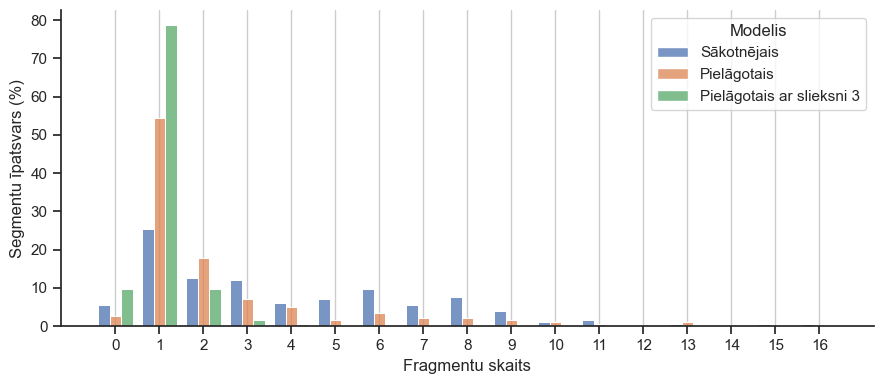

In [837]:
#plot_fragmentation_distribution(fragmentation_df)
# finetuned fragmentation distribution
#plot_fragmentation_distribution(fragmentation_df_finetuned)
fragmentation_df["Modelis"] = "Sākotnējais"
fragmentation_df_finetuned["Modelis"] = "Pielāgotais"
fragmentation_df_finetuned_acc3["Modelis"] = "Pielāgotais ar slieksni 3"
fragmentation_df_inertia_1_10["Modelis"] = "inertia 1 10"
fragmentation_df_inertia_2_10["Modelis"] = "inertia 2 10"



plot_fragmentation_distribution_comparison(
    [fragmentation_df, fragmentation_df_finetuned, fragmentation_df_finetuned_acc3],
    model_order=["Sākotnējais", "Pielāgotais", "Pielāgotais ar slieksni 3"]
)

### per exercise

In [761]:
#plot_one_fragment_percentage_per_exercise(fragmentation_df)

In [762]:
#plot_fragmentation_per_exercise(fragmentation_df)
# finetuned fragmentation per exercise
#plot_fragmentation_per_exercise(fragmentation_df_finetuned)

### per session

In [763]:
display(calculate_fragmentation_per_session(fragmentation_df).style.format(decimal=",", precision=2))
# finetuned fragmentation per session
display(calculate_fragmentation_per_session(fragmentation_df_finetuned).style.format(decimal=",", precision=2))
# finetuned acc3 fragmentation per session
display(calculate_fragmentation_per_session(fragmentation_df_finetuned_acc3).style.format(decimal=",", precision=2))
display(calculate_fragmentation_per_session(fragmentation_df_inertia_1_10).style.format(decimal=",", precision=2))
display(calculate_fragmentation_per_session(fragmentation_df_inertia_2_10).style.format(decimal=",", precision=2))



,session,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,session_1776786984700,"2,05","1,00","1,00","2,75",8,"2,24","50,00","36,36","27,27","18,18","9,09",22,3,"13,64"
1,session_1776875240569,"4,38","4,50","2,75","6,00",9,"2,47","18,75","81,25","75,00","62,50","50,00",16,0,"0,00"
2,session_1776938763711,"2,94","2,00","1,00","4,50",8,"2,79","31,25","56,25","37,50","31,25","25,00",16,2,"12,50"
3,session_1777025558126,"6,06","6,00","1,75","8,00",16,"4,75","18,75","75,00","68,75","68,75","62,50",16,1,"6,25"
4,session_1777104300830,"2,50","2,00","1,75","3,00",8,"1,70","20,00","75,00","40,00","20,00","5,00",20,1,"5,00"
5,session_1777394359098,"4,16","4,00","1,00","6,00",13,"3,16","21,88","71,88","62,50","53,12","46,88",32,2,"6,25"
6,session_1777462103399,"3,39","2,50","1,00","5,50",11,"3,15","27,78","61,11","50,00","33,33","27,78",18,2,"11,11"
7,session_1779544010630,"6,25","7,00","5,00","8,25",9,"2,72","12,50","87,50","87,50","81,25","81,25",16,0,"0,00"
8,session_1779608056714,"2,72","2,50","1,00","3,00",9,"2,14","38,89","61,11","50,00","16,67","16,67",18,0,"0,00"
9,session_1779628611903,"5,13","6,00","2,00","6,50",11,"3,05","13,04","86,96","69,57","60,87","60,87",23,0,"0,00"


,session,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,session_1776786984700,"1,91","1,00","1,00","2,00",8,"1,85","63,64","31,82","22,73","18,18","9,09",22,1,"4,55"
1,session_1776875240569,"1,31","1,00","1,00","1,25",3,"0,60","75,00","25,00","6,25","0,00","0,00",16,0,"0,00"
2,session_1776938763711,"2,19","1,00","1,00","3,00",6,"1,76","56,25","43,75","31,25","18,75","12,50",16,0,"0,00"
3,session_1777025558126,"2,56","1,50","1,00","2,25",13,"3,08","50,00","50,00","25,00","12,50","12,50",16,0,"0,00"
4,session_1777104300830,"2,25","1,00","1,00","2,50",8,"2,22","45,00","45,00","25,00","25,00","15,00",20,2,"10,00"
5,session_1777394359098,"2,12","1,00","1,00","3,00",10,"2,04","56,25","40,62","28,12","15,62","9,38",32,1,"3,12"
6,session_1777462103399,"2,39","2,00","1,00","3,00",7,"1,69","38,89","61,11","33,33","22,22","11,11",18,0,"0,00"
7,session_1779544010630,"3,31","2,00","1,00","4,75",10,"3,24","43,75","56,25","31,25","31,25","25,00",16,0,"0,00"
8,session_1779608056714,"1,22","1,00","1,00","1,00",3,"0,65","72,22","22,22","5,56","0,00","0,00",18,1,"5,56"
9,session_1779628611903,"3,91","2,00","1,00","6,50",13,"3,81","43,48","56,52","39,13","34,78","34,78",23,0,"0,00"


,session,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,session_1776786984700,"1,00","1,00","1,00","1,00",2,"0,31","90,91","4,55","0,00","0,00","0,00",22,1,"4,55"
1,session_1776875240569,"1,00","1,00","1,00","1,00",1,"0,00","100,00","0,00","0,00","0,00","0,00",16,0,"0,00"
2,session_1776938763711,"1,00","1,00","1,00","1,00",1,"0,00","100,00","0,00","0,00","0,00","0,00",16,0,"0,00"
3,session_1777025558126,"1,12","1,00","1,00","1,00",2,"0,34","87,50","12,50","0,00","0,00","0,00",16,0,"0,00"
4,session_1777104300830,"1,00","1,00","1,00","1,00",2,"0,56","70,00","15,00","0,00","0,00","0,00",20,3,"15,00"
5,session_1777394359098,"0,94","1,00","1,00","1,00",3,"0,67","65,62","12,50","3,12","0,00","0,00",32,7,"21,88"
6,session_1777462103399,"0,94","1,00","1,00","1,00",3,"0,73","66,67","11,11","5,56","0,00","0,00",18,4,"22,22"
7,session_1779544010630,"1,06","1,00","1,00","1,00",2,"0,44","81,25","12,50","0,00","0,00","0,00",16,1,"6,25"
8,session_1779608056714,"1,06","1,00","1,00","1,00",2,"0,42","83,33","11,11","0,00","0,00","0,00",18,1,"5,56"
9,session_1779628611903,"1,35","1,00","1,00","2,00",4,"0,88","60,87","30,43","8,70","4,35","0,00",23,2,"8,70"


,session,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,session_1776786984700,"1,32","1,00","1,00","1,00",5,"1,04","81,82","13,64","13,64","4,55","4,55",22,1,"4,55"
1,session_1776875240569,"1,06","1,00","1,00","1,00",2,"0,25","93,75","6,25","0,00","0,00","0,00",16,0,"0,00"
2,session_1776938763711,"1,06","1,00","1,00","1,00",2,"0,25","93,75","6,25","0,00","0,00","0,00",16,0,"0,00"
3,session_1777025558126,"1,56","1,00","1,00","1,00",9,"2,00","87,50","12,50","6,25","6,25","6,25",16,0,"0,00"
4,session_1777104300830,"1,30","1,00","1,00","1,00",7,"1,42","75,00","15,00","5,00","5,00","5,00",20,2,"10,00"
5,session_1777394359098,"1,56","1,00","1,00","1,25",6,"1,29","71,88","25,00","15,62","9,38","6,25",32,1,"3,12"
6,session_1777462103399,"1,56","1,00","1,00","1,00",5,"1,20","77,78","22,22","16,67","11,11","5,56",18,0,"0,00"
7,session_1779544010630,"1,06","1,00","1,00","1,00",2,"0,25","93,75","6,25","0,00","0,00","0,00",16,0,"0,00"
8,session_1779608056714,"1,00","1,00","1,00","1,00",1,"0,00","100,00","0,00","0,00","0,00","0,00",18,0,"0,00"
9,session_1779628611903,"1,70","1,00","1,00","2,00",6,"1,33","69,57","30,43","17,39","13,04","4,35",23,0,"0,00"


,session,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,session_1776786984700,"1,05","1,00","1,00","1,00",2,"0,38","86,36","9,09","0,00","0,00","0,00",22,1,"4,55"
1,session_1776875240569,"1,06","1,00","1,00","1,00",2,"0,25","93,75","6,25","0,00","0,00","0,00",16,0,"0,00"
2,session_1776938763711,"1,00","1,00","1,00","1,00",1,"0,00","100,00","0,00","0,00","0,00","0,00",16,0,"0,00"
3,session_1777025558126,"1,12","1,00","1,00","1,00",2,"0,34","87,50","12,50","0,00","0,00","0,00",16,0,"0,00"
4,session_1777104300830,"1,05","1,00","1,00","1,00",2,"0,51","75,00","15,00","0,00","0,00","0,00",20,2,"10,00"
5,session_1777394359098,"0,94","1,00","1,00","1,00",2,"0,44","81,25","6,25","0,00","0,00","0,00",32,4,"12,50"
6,session_1777462103399,"1,22","1,00","1,00","1,00",3,"0,65","72,22","22,22","5,56","0,00","0,00",18,1,"5,56"
7,session_1779544010630,"1,06","1,00","1,00","1,00",2,"0,25","93,75","6,25","0,00","0,00","0,00",16,0,"0,00"
8,session_1779608056714,"1,00","1,00","1,00","1,00",1,"0,00","100,00","0,00","0,00","0,00","0,00",18,0,"0,00"
9,session_1779628611903,"1,26","1,00","1,00","1,00",3,"0,75","78,26","17,39","13,04","0,00","0,00",23,1,"4,35"


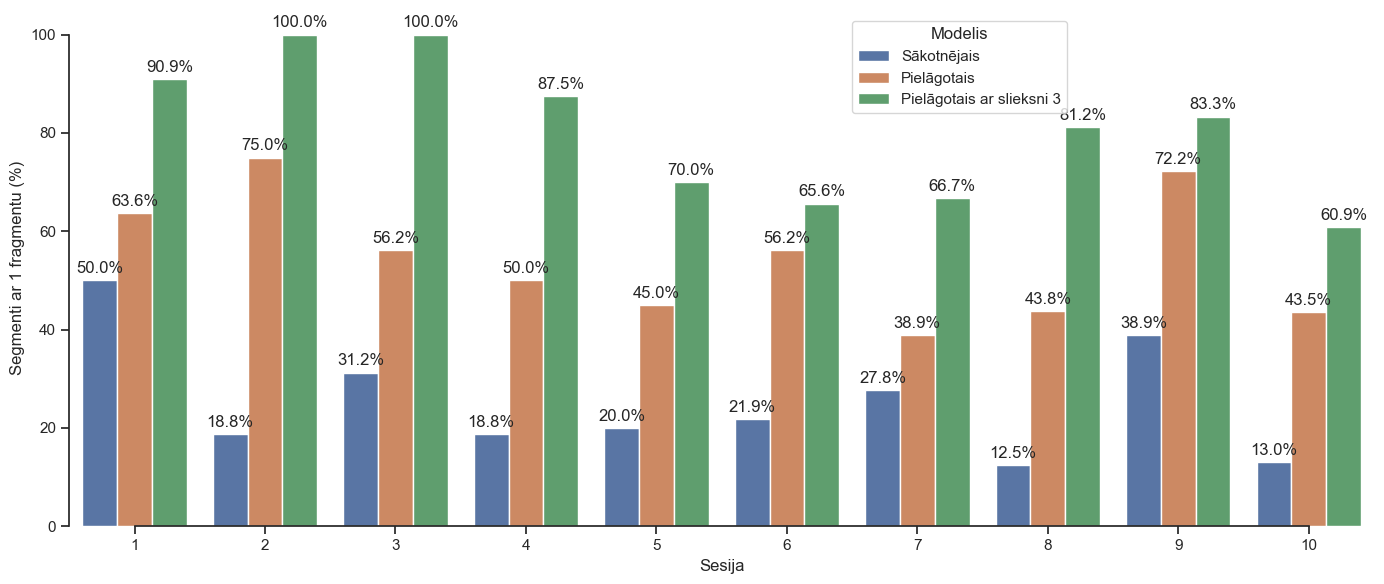

In [866]:
# plot "segmenti ar 1 fragmentu (%)" per session comparison
def plot_one_fragment_percentage_per_session_comparison(fragmentation_dfs, model_order=["Sākotnējais", "Pielāgotais", "Pielāgotais ar slieksni 3"]):
    combined_df = pd.concat(fragmentation_dfs, ignore_index=True)

    combined_df["session_id"] = combined_df["session_id"]

    # Calculate percentage of segments with 1 fragment per session and model
    summary_df = (
        combined_df
        .groupby(["session_id", "Modelis"])
        .apply(lambda x: (x["fragment_count"] == 1).mean() * 100)
        .reset_index(name="Segmenti ar 1 fragmentu (%)")
    )

    f, ax = plt.subplots(figsize=(14, 6))

    sns.barplot(
        data=summary_df,
        x="session_id",
        y="Segmenti ar 1 fragmentu (%)",
        hue="Modelis",
        hue_order=model_order,
        ax=ax
    )

    ax.set(
        xlabel="Sesija",
        ylabel="Segmenti ar 1 fragmentu (%)",
        title=""
    )

    # add percentage labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)


    # Remove duplicate legends from boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(fragmentation_dfs)],
        labels[:len(fragmentation_dfs)],
        title="Modelis",
        loc=(0.6, 0.8)
    )

    # fix x axis to go to 0

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

plot_one_fragment_percentage_per_session_comparison(
    [fragmentation_df, fragmentation_df_finetuned, fragmentation_df_finetuned_acc3],
)

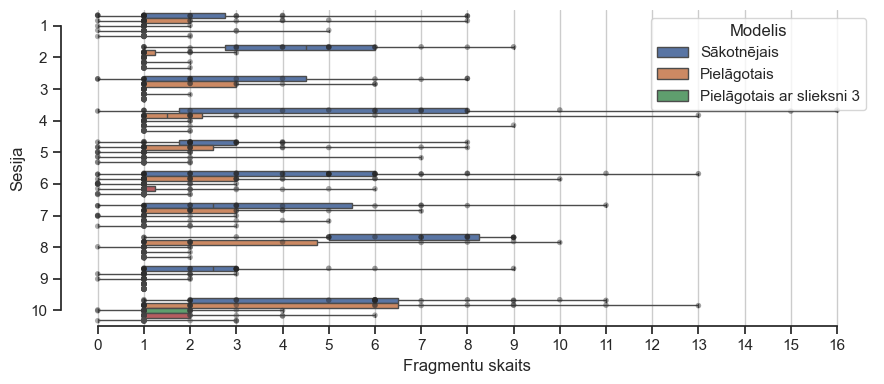

In [765]:
#plot_fragmentation_per_session(fragmentation_df)
# finetuned fragmentation per session
#plot_fragmentation_per_session(fragmentation_df_finetuned)

plot_fragmentation_per_session_comparison(
    [fragmentation_df,
    fragmentation_df_finetuned,
    fragmentation_df_finetuned_acc3,
    fragmentation_df_inertia_1_10,
    fragmentation_df_inertia_2_10]
)

In [766]:
# plot_fragmentation_per_session_comparison(
#     fragmentation_df_finetuned,
#     fragmentation_df_finetuned_acc3
# )

### Per muscle group

In [767]:
display(calculate_fragmentation_per_group(fragmentation_df).style.format(decimal=",", precision=2))
# finetuned fragmentation per group
display(calculate_fragmentation_per_group(fragmentation_df_finetuned).style.format(decimal=",", precision=2))

,group,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,Bicepsi,"3,91","2,00","1,00","7,00",11,"3,26","39,13","60,87","47,83","39,13","39,13",23,0,"0,00"
1,Krūtis,"3,13","2,50","1,00","5,00",9,"2,52","30,00","60,00","50,00","40,00","33,33",30,3,"10,00"
2,Kājas,"3,89","3,00","1,00","6,00",15,"3,17","33,33","66,67","57,78","42,22","33,33",45,0,"0,00"
3,Mugura,"4,72","5,00","2,00","6,00",16,"3,59","6,90","82,76","68,97","58,62","51,72",29,3,"10,34"
4,Pleci,"4,41","3,50","1,25","8,00",11,"3,69","9,09","72,73","54,55","50,00","45,45",22,4,"18,18"
5,Tricepsi,"2,83","2,50","1,00","4,00",7,"1,81","33,33","66,67","50,00","33,33","20,83",24,0,"0,00"
6,Vēders,"4,54","3,00","1,75","7,00",13,"3,49","20,83","75,00","62,50","45,83","45,83",24,1,"4,17"


,group,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,Bicepsi,"1,87","1,00","1,00","1,50",8,"1,94","73,91","26,09","17,39","13,04","8,70",23,0,"0,00"
1,Krūtis,"1,60","1,00","1,00","2,00",6,"1,33","60,00","33,33","13,33","10,00","6,67",30,2,"6,67"
2,Kājas,"2,64","2,00","1,00","3,00",13,"2,76","44,44","55,56","28,89","17,78","11,11",45,0,"0,00"
3,Mugura,"1,66","1,00","1,00","2,00",6,"1,23","58,62","37,93","13,79","10,34","3,45",29,1,"3,45"
4,Pleci,"3,36","3,00","1,00","4,75",10,"2,59","31,82","68,18","54,55","31,82","27,27",22,0,"0,00"
5,Tricepsi,"2,08","1,00","1,00","2,00",10,"2,41","70,83","29,17","16,67","12,50","12,50",24,0,"0,00"
6,Vēders,"3,25","1,00","1,00","5,25",13,"3,43","45,83","45,83","37,50","37,50","29,17",24,2,"8,33"


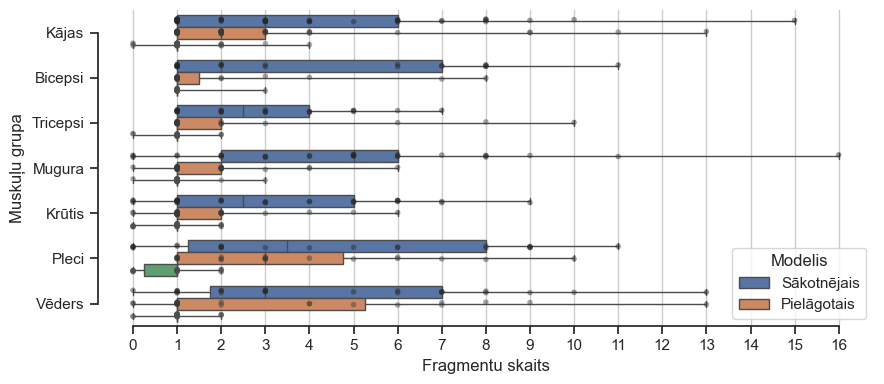

In [768]:
#plot_fragmentation_per_group(fragmentation_df)
# finetuned fragmentation per group
#plot_fragmentation_per_group(fragmentation_df_finetuned)
plot_fragmentation_per_group_comparison(
    [fragmentation_df,
    fragmentation_df_finetuned,
    fragmentation_df_finetuned_acc3]
)

In [769]:
# plot_fragmentation_per_group_comparison(
#     fragmentation_df_finetuned,
#     fragmentation_df_finetuned_acc3
# )

## Resting analysis

In [770]:
def calculate_false_rest_activation_runs(
    rest_segments,
    prediction_col="prediction_binary",
    timestamp_col="timestamp"
):
    results = []

    for rest_segment_id, segment in enumerate(rest_segments, start=1):
        segment = segment.sort_values(timestamp_col).copy()

        preds = segment[prediction_col].fillna(0).astype(int).to_numpy()
        timestamps = segment[timestamp_col].to_numpy()

        in_activation = False
        activation_start = None

        for i, pred in enumerate(preds):
            ts = timestamps[i]

            if pred == 1 and not in_activation:
                activation_start = ts
                in_activation = True

            elif pred == 0 and in_activation:
                activation_end = ts

                results.append({
                    "rest_segment_id": rest_segment_id,
                    "session": segment["session"].iloc[0],
                    "session_id": segment["session_id"].iloc[0],
                    "activation_start": activation_start,
                    "activation_end": activation_end,
                    "activation_duration_s": (activation_end - activation_start) / 1000,
                })

                in_activation = False
                activation_start = None

        if in_activation:
            activation_end = timestamps[-1]

            results.append({
                "rest_segment_id": rest_segment_id,
                "session": segment["session"].iloc[0],
                "session_id": segment["session_id"].iloc[0],
                "activation_start": activation_start,
                "activation_end": activation_end,
                "activation_duration_s": (activation_end - activation_start) / 1000,
            })

    return pd.DataFrame(results)

In [771]:
def calculate_false_rest_activations(
    rest_segments,
    prediction_col="prediction_binary"
):
    activation_runs = calculate_false_rest_activation_runs(
        rest_segments,
        prediction_col=prediction_col
    )

    results = []

    for rest_segment_id, segment in enumerate(rest_segments, start=1):
        rest_duration_s = (
            segment["timestamp"].max() -
            segment["timestamp"].min()
        ) / 1000

        if activation_runs.empty:
            activation_count = 0
        else:
            activation_count = (
                activation_runs["rest_segment_id"] == rest_segment_id
            ).sum()

        results.append({
            "rest_segment_id": rest_segment_id,
            "session": segment["session"].iloc[0],
            "session_id": segment["session_id"].iloc[0],
            "false_activation_count": activation_count,
            "rest_duration_s": rest_duration_s
        })

    return pd.DataFrame(results), activation_runs

In [772]:
rest_segments = get_rest_segments(windows_df)
rest_segments_finetuned_acc3 = get_rest_segments(df_acc_finetuned_3)
rest_segments_inertia = get_rest_segments(df_inertia)

rest_activation_df, false_activation_runs = calculate_false_rest_activations(
    rest_segments,
    prediction_col="prediction_binary"
)

rest_activation_df_finetuned, false_activation_runs_finetuned = calculate_false_rest_activations(
    rest_segments,
    prediction_col="prediction_finetuned_binary"
)

rest_activation_df_finetuned_acc3, false_activation_runs_finetuned_acc3 = calculate_false_rest_activations(
    rest_segments_finetuned_acc3,
    prediction_col="prediction_finetuned_accumulator_3"
)

rest_activation_df_inertia_1_10, false_activation_runs_inertia_1_10 = calculate_false_rest_activations(
    rest_segments_inertia,
    prediction_col="prediction_inertia_1_10"
)

rest_activation_df_inertia_2_10, false_activation_runs_inertia_2_10 = calculate_false_rest_activations(
    rest_segments_inertia,
    prediction_col="prediction_inertia_2_10"
)

In [773]:
def calculate_rest_activation_statistics(
    rest_activation_df,
    false_activation_runs
):
    fac = rest_activation_df["false_activation_count"]
    false_mask = fac > 0

    activations_per_min = (
        fac /
        (rest_activation_df["rest_duration_s"] / 60)
    )

    durations = false_activation_runs["activation_duration_s"].dropna()

    stats = {
        "Vidējais": fac.mean(),
        "Mediānais": fac.median(),
        "Q1": fac.quantile(0.25),
        "Q3": fac.quantile(0.75),
        "Standartnovirze": fac.std(),
        "Maksimālais": fac.max(),

        "Atpūtas segmenti bez kļūdainām aktivizācijām":
            (~false_mask).sum(),

        "Atpūtas segmenti ar kļūdainām aktivizācijām":
            false_mask.sum(),

        "Kļūdaino aktivizāciju īpatsvars (%)":
            false_mask.mean() * 100,

        "Vidējās aktivizācijas minūtē":
            activations_per_min.mean(),
    }

    if durations.empty:
        duration_stats = {
            "Vidējais aktivizāciju ilgums (s)": 0,
            "Mediānais aktivizācijas ilgums (s)": 0,
            "Q1 aktivizācijas ilgums (s)": 0,
            "Q3 aktivizācijas ilgums (s)": 0,

            "Aktivizācijas ar ilgumu >= 1 s (%)": 0,
            "Aktivizācijas ar ilgumu >= 2 s (%)": 0,
            "Aktivizācijas ar ilgumu >= 3 s (%)": 0,
            "Aktivizācijas ar ilgumu >= 5 s (%)": 0,
            "Aktivizācijas ar ilgumu >= 10 s (%)": 0,
        }
    else:
        duration_stats = {
            "Vidējais aktivizāciju ilgums (s)": durations.mean(),
            "Mediānais aktivizācijas ilgums (s)": durations.median(),
            "Q1 aktivizācijas ilgums (s)": durations.quantile(0.25),
            "Q3 aktivizācijas ilgums (s)": durations.quantile(0.75),

            "Aktivizācijas ar ilgumu >= 1 s (%)": (durations >= 1).mean() * 100,
            "Aktivizācijas ar ilgumu >= 2 s (%)": (durations >= 2).mean() * 100,
            "Aktivizācijas ar ilgumu >= 3 s (%)": (durations >= 3).mean() * 100,
            "Aktivizācijas ar ilgumu >= 5 s (%)": (durations >= 5).mean() * 100,
            "Aktivizācijas ar ilgumu >= 10 s (%)": (durations >= 10).mean() * 100,
        }

    stats.update(duration_stats)

    return pd.DataFrame([stats])

### Rest activation statistics

In [774]:
result_regular = calculate_rest_activation_statistics(
    rest_activation_df,
    false_activation_runs
)

result_finetuned = calculate_rest_activation_statistics(
    rest_activation_df_finetuned,
    false_activation_runs_finetuned
)

result_finetuned_acc3 = calculate_rest_activation_statistics(
    rest_activation_df_finetuned_acc3,
    false_activation_runs_finetuned_acc3
)

result_inertia_1_10 = calculate_rest_activation_statistics(
    rest_activation_df_inertia_1_10,
    false_activation_runs_inertia_1_10
)

result_inertia_2_10 = calculate_rest_activation_statistics(
    rest_activation_df_inertia_2_10,
    false_activation_runs_inertia_2_10
)

combined = pd.concat(
    [result_regular, result_finetuned, result_finetuned_acc3, result_inertia_1_10, result_inertia_2_10],
    axis=0,
    keys=["Regular", "Finetuned", "Finetuned (Accumulator 3)", "Inertia 1 10", "Inertia 2 10"]
)

In [775]:
display(combined.transpose().style.format(decimal=",", precision=2))

,Regular,Finetuned,Finetuned (Accumulator 3),Inertia 1 10,Inertia 2 10
,0,0,0,0,0
Vidējais,"7,35","4,18","1,58","4,03","2,30"
Mediānais,"5,00","3,00","1,00","3,00","2,00"
Q1,"2,00","1,00","1,00","2,00","1,00"
Q3,"10,50","5,00","2,00","5,00","3,00"
Standartnovirze,"8,19","5,14","1,70","4,18","2,24"
Maksimālais,"56,00","39,00","12,00","34,00","16,00"
Atpūtas segmenti bez kļūdainām aktivizācijām,"25,00","41,00","55,00","23,00","29,00"
Atpūtas segmenti ar kļūdainām aktivizācijām,"198,00","182,00","168,00","200,00","194,00"
Kļūdaino aktivizāciju īpatsvars (%),"88,79","81,61","75,34","89,69","87,00"


# Aizkave

## Methods

In [776]:
def prediction_runs_to_segments(
    windows_df,
    prediction_col="prediction_binary",
    timestamp_col="timestamp",
    session_col="session",
    session_id_col="session_id",
    max_gap_ms=3000
):
    """
    Converts window-level binary predictions into predicted exercise-state segments.

    Segment start:
        timestamp of the first positive prediction.

    Segment end:
        timestamp of the first negative prediction after the positive run,
        because that is when the system would leave the exercise state.

    If a session ends while still in exercise state, the segment ends at the last
    available prediction timestamp.
    """
    df = windows_df.copy()
    df = df.sort_values([session_col, timestamp_col])

    segments = []

    for (session, session_id), session_df in df.groupby([session_col, session_id_col]):
        session_df = session_df.sort_values(timestamp_col).copy()

        in_segment = False
        start_time = None
        last_time = None

        for _, row in session_df.iterrows():
            ts = row[timestamp_col]
            pred = int(row[prediction_col]) if not pd.isna(row[prediction_col]) else 0

            # If there is a large gap, close the segment at the last known timestamp.
            # We do not know what happened during the gap.
            if in_segment and last_time is not None and ts - last_time > max_gap_ms:
                segments.append({
                    "session": session,
                    "session_id": session_id,
                    "pred_start": start_time,
                    "pred_end": last_time,
                    "end_reason": "gap"
                })

                in_segment = False
                start_time = None

            if pred == 1 and not in_segment:
                start_time = ts
                in_segment = True

            elif pred == 0 and in_segment:
                segments.append({
                    "session": session,
                    "session_id": session_id,
                    "pred_start": start_time,
                    "pred_end": ts,
                    "end_reason": "first_negative"
                })

                in_segment = False
                start_time = None

            last_time = ts

        # If the session ends while still in exercise state,
        # we can only close at the last known timestamp.
        if in_segment:
            segments.append({
                "session": session,
                "session_id": session_id,
                "pred_start": start_time,
                "pred_end": last_time,
                "end_reason": "session_end"
            })

    return pd.DataFrame(segments)

In [777]:
def calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_binary",
    timestamp_col="timestamp",
    max_gap_ms=3000
):
    """
    Calculates start and end latency for annotated exercise segments.

    A segment is counted as detected only if at least one predicted exercise
    segment overlaps the annotated exercise interval.

    Start latency:
        earliest overlapping predicted segment start - annotated start

    End latency:
        latest overlapping predicted segment end - annotated end
    """
    pred_segments = prediction_runs_to_segments(
        windows_df,
        prediction_col=prediction_col,
        timestamp_col=timestamp_col,
        max_gap_ms=max_gap_ms
    )

    results = []

    for i, event in events_df.iterrows():
        true_start = event["start_watch"]
        true_end = event["end_watch"]
        session = event["session"]
        session_id = event["session_id"]

        overlapping = pred_segments[
            (pred_segments["session"] == session) &
            (pred_segments["pred_end"] >= true_start) &
            (pred_segments["pred_start"] <= true_end)
        ].copy()

        if overlapping.empty:
            results.append({
                "segment_id": i + 1,
                "name": event["name"],
                "group": event["group"],
                "session": session,
                "session_id": session_id,
                "start_watch": true_start,
                "end_watch": true_end,

                "predicted_fragment_count": 0,

                "pred_start": np.nan,
                "pred_end": np.nan,
                "start_latency_ms": np.nan,
                "end_latency_ms": np.nan,
                "start_latency_sec": np.nan,
                "end_latency_sec": np.nan,
                "status": "Not Detected"
            })
            continue

        first_pred_segment = overlapping.sort_values("pred_start").iloc[0]
        last_pred_segment = overlapping.sort_values("pred_end").iloc[-1]

        pred_start = first_pred_segment["pred_start"]
        pred_end = last_pred_segment["pred_end"]

        start_latency_ms = pred_start - true_start
        end_latency_ms = pred_end - true_end

        results.append({
            "segment_id": i + 1,
            "name": event["name"],
            "group": event["group"],
            "session": session,
            "session_id": session_id,
            "start_watch": true_start,
            "end_watch": true_end,

            "predicted_fragment_count": len(overlapping),

            "pred_start": pred_start,
            "pred_end": pred_end,
            "start_latency_ms": start_latency_ms,
            "end_latency_ms": end_latency_ms,
            "start_latency_sec": start_latency_ms / 1000,
            "end_latency_sec": end_latency_ms / 1000,
            "status": "Detected"
        })

    return pd.DataFrame(results)

### Stats methods

In [778]:
def calculate_latency_statistics(latency_df, latency_col="start_latency_sec"):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    values = detected[latency_col].dropna()

    stats = {
        "Vidējais": values.mean(),
        "Mediāna": values.median(),
        "Standartnovirze": values.std(),
        "Minimums": values.min(),
        "Maksimums": values.max(),
        "1. kvartile": values.quantile(0.25),
        "3. kvartile": values.quantile(0.75),
        "P95": values.quantile(0.95),
        "Segmentu skaits": len(latency_df),
        "Detektēti segmenti": len(detected),
        "Nedetektēti segmenti": (latency_df["status"] != "Detected").sum(),
        "Detektēti segmenti (%)": (latency_df["status"] == "Detected").mean() * 100,
        "Aizkave ≤ 1 s (%)": (values.abs() <= 1).mean() * 100,
        "Aizkave ≤ 2 s (%)": (values.abs() <= 2).mean() * 100,
        "Aizkave ≤ 3 s (%)": (values.abs() <= 3).mean() * 100,
        "Aizkave ≤ 5 s (%)": (values.abs() <= 5).mean() * 100,
        "Aizkave ≤ 10 s (%)": (values.abs() <= 10).mean() * 100,
    }

    return pd.DataFrame([stats]).T

### plots

In [779]:
def plot_latency_statistics_combined(
    latency_df,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title=None,
    xlim=(-10, 10)
):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return

    sns.set_theme(style="ticks")
    f, ax = plt.subplots(figsize=(10, 2))

    sns.boxplot(
        data=detected,
        x=latency_col,
        whis=[0, 100],
        width=.6,
        color="skyblue",
        ax=ax
    )

    sns.stripplot(
        data=detected,
        x=latency_col,
        size=4,
        color=".3",
        alpha=0.5,
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set(
        ylabel="Visi segmenti",
        xlabel=xlabel,
        title=title
    )

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))
    ax.xaxis.grid(True)

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

In [780]:
def plot_latency_comparison_combined(
    latency_dfs,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    ylabel="Modelis",
    title="Vingrošanas noteikšanas aizkaves salīdzinājums",
    xlim=(-5, 10)
):
    combined = pd.concat(latency_dfs, ignore_index=True)

    if combined.empty:
        print("No detected events to plot.")
        return

    sns.set_theme(style="ticks")

    f, ax = plt.subplots(figsize=(10, 3))

    sns.boxplot(
        data=combined,
        x=latency_col,
        y="Modelis",
        hue="Modelis",
        whis=[0, 100],
        width=.6,
        palette="vlag",
        legend=False,
        ax=ax
    )

    sns.stripplot(
        data=combined,
        x=latency_col,
        y="Modelis",
        size=4,
        color=".3",
        alpha=0.5,
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)

    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title
    )

    plt.ylabel(ylabel, rotation=90)

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [781]:
def plot_latency_statistics_per_session(
    latency_df,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkave pa sesijām",
    xlim=(-5, 10)
):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return

    detected["session_id"] = detected["session_id"].astype(int)

    num_categories = detected["session_id"].nunique()
    dynamic_height = max(2, num_categories * 0.35)

    f, ax = plt.subplots(figsize=(8, dynamic_height))

    sns.boxplot(
        data=detected,
        x=latency_col,
        y="session_id",
        hue="session_id",
        whis=[0, 100],
        width=.6,
        palette="vlag",
        legend=False,
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=detected,
        x=latency_col,
        y="session_id",
        size=4,
        color=".3",
        alpha=0.6,
        orient="h",
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)
    ax.set(
        xlabel=xlabel,
        ylabel="Sesija",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [782]:
def plot_latency_statistics_per_group(
    latency_df,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkave pa muskuļu grupām",
    xlim=(-5, 10),
    group_order=None
):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return

    if group_order is not None:
        detected["group"] = pd.Categorical(
            detected["group"],
            categories=group_order,
            ordered=True
        )
        detected = detected.sort_values("group")

    num_categories = detected["group"].nunique()
    dynamic_height = max(2.5, num_categories * 0.45)

    f, ax = plt.subplots(figsize=(8, dynamic_height))

    sns.boxplot(
        data=detected,
        x=latency_col,
        y="group",
        hue="group",
        whis=[0, 100],
        width=.6,
        palette="vlag",
        legend=False,
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=detected,
        x=latency_col,
        y="group",
        size=4,
        color=".3",
        alpha=0.6,
        orient="h",
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)
    ax.set(
        xlabel=xlabel,
        ylabel="Muskuļu grupa",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [783]:
def plot_latency_comparison_per_session(
    latency_dfs,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkaves salīdzinājums pa sesijām",
    xlim=(-5, 10)
):
    combined = pd.concat(latency_dfs, ignore_index=True)

    combined["session_id"] = combined["session_id"].astype(int)

    num_sessions = combined["session_id"].nunique()
    dynamic_height = max(2.5, num_sessions * 0.55)

    f, ax = plt.subplots(figsize=(9, dynamic_height))

    sns.boxplot(
        data=combined,
        x=latency_col,
        y="session_id",
        hue="Modelis",
        whis=[0, 100],
        width=.65,
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=combined,
        x=latency_col,
        y="session_id",
        hue="Modelis",
        dodge=True,
        size=3,
        palette="dark:.3",
        alpha=0.45,
        orient="h",
        ax=ax
    )

    # Remove duplicated legend entries caused by boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:3],
        labels[:3],
        title="Modelis",
        loc="best"
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)

    ax.set(
        xlabel=xlabel,
        ylabel="Sesija",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [784]:
def plot_latency_statistics_per_group(
    latency_df,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkave pa muskuļu grupām",
    xlim=(-5, 10),
    group_order=None
):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return

    if group_order is not None:
        detected["group"] = pd.Categorical(
            detected["group"],
            categories=group_order,
            ordered=True
        )
        detected = detected.sort_values("group")

    num_categories = detected["group"].nunique()
    dynamic_height = max(2.5, num_categories * 0.45)

    f, ax = plt.subplots(figsize=(8, dynamic_height))

    sns.boxplot(
        data=detected,
        x=latency_col,
        y="group",
        hue="group",
        whis=[0, 100],
        width=.6,
        palette="vlag",
        legend=False,
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=detected,
        x=latency_col,
        y="group",
        size=4,
        color=".3",
        alpha=0.6,
        orient="h",
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)
    ax.set(
        xlabel=xlabel,
        ylabel="Muskuļu grupa",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [785]:
def plot_latency_comparison_per_group(
    latency_dfs,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkaves salīdzinājums pa muskuļu grupām",
    xlim=(-5, 10),
    group_order=None
):
    model_order = [latency_df["Modelis"].iloc[0] for latency_df in latency_dfs]

    combined = pd.concat(latency_dfs, ignore_index=True)

    if group_order is not None:
        combined["group"] = pd.Categorical(
            combined["group"],
            categories=group_order,
            ordered=True
        )
        combined = combined.sort_values("group")

    num_groups = combined["group"].nunique()
    dynamic_height = max(2.5, num_groups * 0.6)

    f, ax = plt.subplots(figsize=(9, dynamic_height))

    sns.boxplot(
        data=combined,
        x=latency_col,
        y="group",
        hue="Modelis",
        hue_order=model_order,
        whis=[0, 100],
        width=.65,
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=combined,
        x=latency_col,
        y="group",
        hue="Modelis",
        hue_order=model_order,
        dodge=True,
        size=3,
        palette="dark:.3",
        alpha=0.45,
        orient="h",
        ax=ax
    )

    # Remove duplicated legend entries caused by boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:len(model_order)],
        labels[:len(model_order)],
        title="Modelis",
        loc="best"
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)

    ax.set(
        xlabel=xlabel,
        ylabel="Muskuļu grupa",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

## Stats

In [786]:
latency_df = calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_binary"
)

latency_df_finetuned = calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_finetuned_binary"
)

latency_df_finetuned_acc3 = calculate_exercise_latency(
    df_acc_finetuned_3,
    events_df,
    prediction_col="prediction_finetuned_accumulator_3"
)

latency_df_inertia_1_10 = calculate_exercise_latency(
    df_inertia,
    events_df,
    prediction_col="prediction_inertia_1_10"
)

latency_df_inertia_2_10 = calculate_exercise_latency(
    df_inertia,
    events_df,
    prediction_col="prediction_inertia_2_10"
)

#display(latency_df_finetuned)

In [787]:
calculated_latency_stats = calculate_latency_statistics(latency_df, latency_col="start_latency_sec").transpose()
calculated_latency_stats_finetuned = calculate_latency_statistics(latency_df_finetuned, latency_col="start_latency_sec").transpose()
calculated_latency_stats_finetuned_acc3 = calculate_latency_statistics(latency_df_finetuned_acc3, latency_col="start_latency_sec").transpose()
calculated_latency_stats_inertia_1_10 = calculate_latency_statistics(latency_df_inertia_1_10, latency_col="start_latency_sec").transpose()
calculated_latency_stats_inertia_2_10 = calculate_latency_statistics(latency_df_inertia_2_10, latency_col="start_latency_sec").transpose()



combined_latency_stats = pd.concat(
    [calculated_latency_stats, calculated_latency_stats_finetuned, calculated_latency_stats_finetuned_acc3, calculated_latency_stats_inertia_1_10,
     calculated_latency_stats_inertia_2_10],
    axis=0,
    keys=["Regular", "Finetuned", "Finetuned (Accumulator 3)", "Inertia 1 10", "Inertia 2 10"]
).transpose()

print("Start latency statistics:")

display(combined_latency_stats.style.format(decimal=",", precision=2))

Start latency statistics:


,Regular,Finetuned,Finetuned (Accumulator 3),Inertia 1 10,Inertia 2 10
,0,0,0,0,0
Vidējais,"2,02","0,63","1,35","-0,96","0,07"
Mediāna,"0,98","0,71","2,62","0,43","1,41"
Standartnovirze,"5,79","5,79","6,41","7,05","7,23"
Minimums,"-25,06","-42,17","-40,16","-42,17","-41,16"
Maksimums,"42,10","29,10","42,17","29,10","34,15"
1. kvartile,"0,00","-0,96","0,16","-2,72","-1,84"
3. kvartile,"2,47","1,74","3,58","1,50","2,51"
P95,"9,70","3,68","7,17","3,21","6,72"
Segmentu skaits,"197,00","197,00","197,00","197,00","197,00"


In [788]:
calculated_latency_stats = calculate_latency_statistics(latency_df, latency_col="end_latency_sec").transpose()
calculated_latency_stats_finetuned = calculate_latency_statistics(latency_df_finetuned, latency_col="end_latency_sec").transpose()
calculated_latency_stats_finetuned_acc3 = calculate_latency_statistics(latency_df_finetuned_acc3, latency_col="end_latency_sec").transpose()
calculated_latency_stats_inertia_1_10 = calculate_latency_statistics(latency_df_inertia_1_10, latency_col="end_latency_sec").transpose()
calculated_latency_stats_inertia_2_10 = calculate_latency_statistics(latency_df_inertia_2_10, latency_col="end_latency_sec").transpose()

combined_latency_stats = pd.concat(
    [calculated_latency_stats, calculated_latency_stats_finetuned, calculated_latency_stats_finetuned_acc3, calculated_latency_stats_inertia_1_10,
     calculated_latency_stats_inertia_2_10],
    axis=0,
    keys=["Regular", "Finetuned", "Finetuned (Accumulator 3)", "Inertia 1 10", "Inertia 2 10"]
).transpose()

print("End Latency Statistics:")

display(combined_latency_stats.style.format(decimal=",", precision=2))

End Latency Statistics:


,Regular,Finetuned,Finetuned (Accumulator 3),Inertia 1 10,Inertia 2 10
,0,0,0,0,0
Vidējais,"-1,44","-0,42","1,54","3,92","4,01"
Mediāna,"-0,38","0,05","2,42","4,45","4,50"
Standartnovirze,"4,98","2,95","5,27","5,26","5,35"
Minimums,"-40,16","-21,26","-36,24","-26,00","-26,00"
Maksimums,"4,34","3,83","7,39","36,91","36,91"
1. kvartile,"-1,68","-0,87","1,40","3,21","3,38"
3. kvartile,"0,56","0,89","3,52","5,72","5,76"
P95,"2,49","2,38","5,12","7,71","7,74"
Segmentu skaits,"197,00","197,00","197,00","197,00","197,00"


## Plot 

In [868]:
latency_df["Modelis"] = "Sākotnējais"
latency_df_finetuned["Modelis"] = "Pielāgotais"
latency_df_finetuned_acc3["Modelis"] = "Pielāgotais\nar slieksni 3"
latency_df_inertia_1_10["Modelis"] = "Inertia 1 10"
latency_df_inertia_2_10["Modelis"] = "Inertia 2 10"

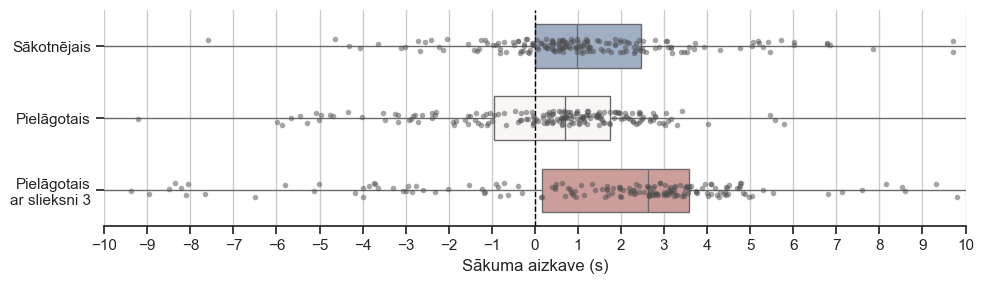

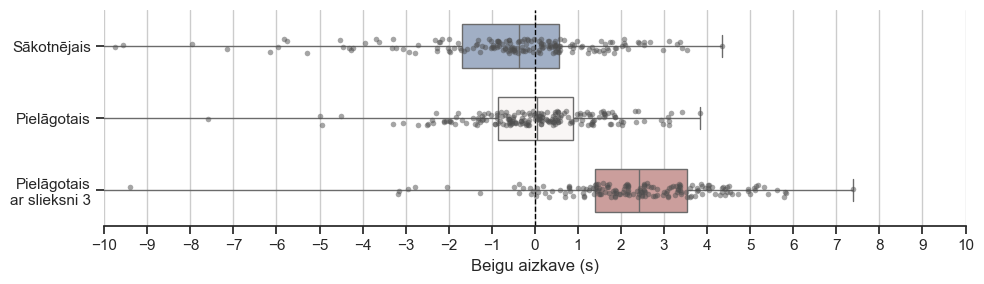

In [869]:
plot_latency_comparison_combined(
    [latency_df,
    latency_df_finetuned,
    latency_df_finetuned_acc3],
    latency_col="start_latency_sec",
    xlabel="Sākuma aizkave (s)",
    ylabel="",
    title="",
    xlim=(-10, 10)
)

plot_latency_comparison_combined(
    [latency_df,
    latency_df_finetuned,
    latency_df_finetuned_acc3],
    latency_col="end_latency_sec",
    xlabel="Beigu aizkave (s)",
    ylabel="",
    title="",
    xlim=(-10, 10)
)

## Plot per session

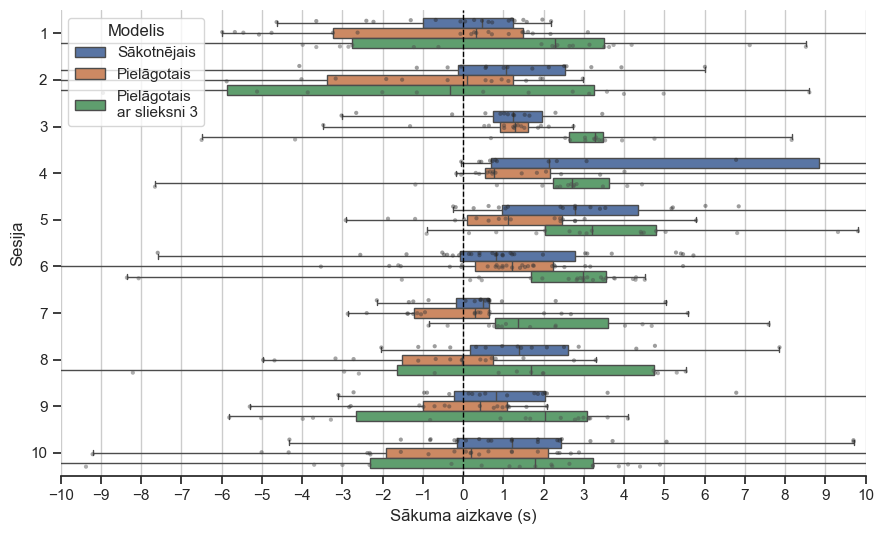

In [791]:
plot_latency_comparison_per_session(
    [latency_df,
    latency_df_finetuned,
    latency_df_finetuned_acc3],
    latency_col="start_latency_sec",
    xlabel="Sākuma aizkave (s)",
    title="",
    xlim=(-10, 10)
)

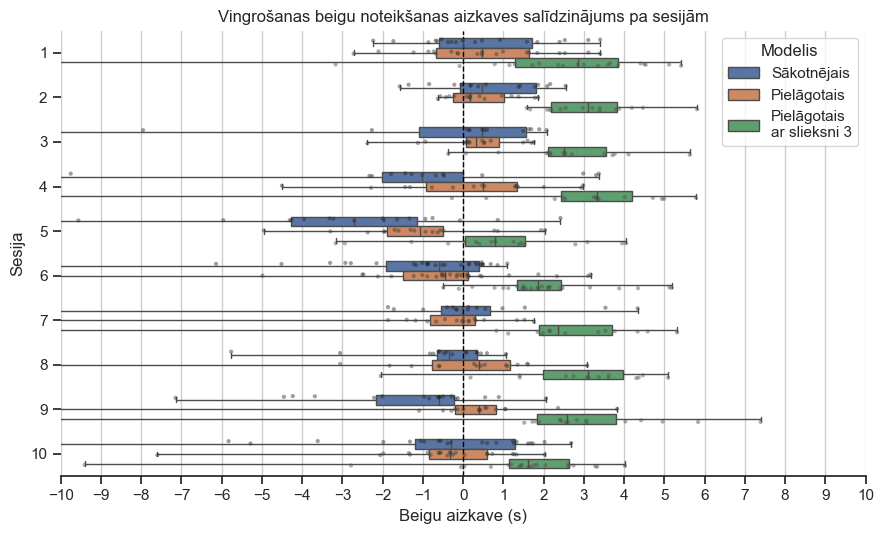

In [792]:
plot_latency_comparison_per_session(
    [latency_df,
    latency_df_finetuned,
    latency_df_finetuned_acc3],
    latency_col="end_latency_sec",
    xlabel="Beigu aizkave (s)",
    title="Vingrošanas beigu noteikšanas aizkaves salīdzinājums pa sesijām",
    xlim=(-10, 10)
)

## Plot per group

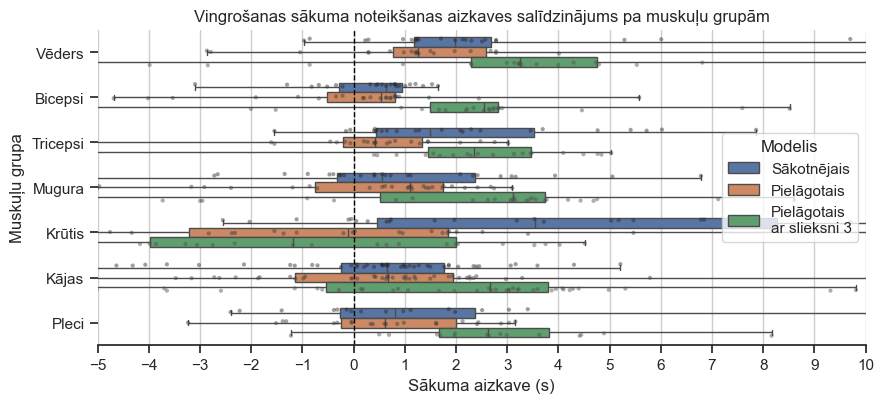

In [793]:
plot_latency_comparison_per_group(
    [latency_df,
     latency_df_finetuned,
     latency_df_finetuned_acc3],
    latency_col="start_latency_sec",
    xlabel="Sākuma aizkave (s)",
    title="Vingrošanas sākuma noteikšanas aizkaves salīdzinājums pa muskuļu grupām",
    xlim=(-5, 10),
    group_order=GROUP_ORDER
)

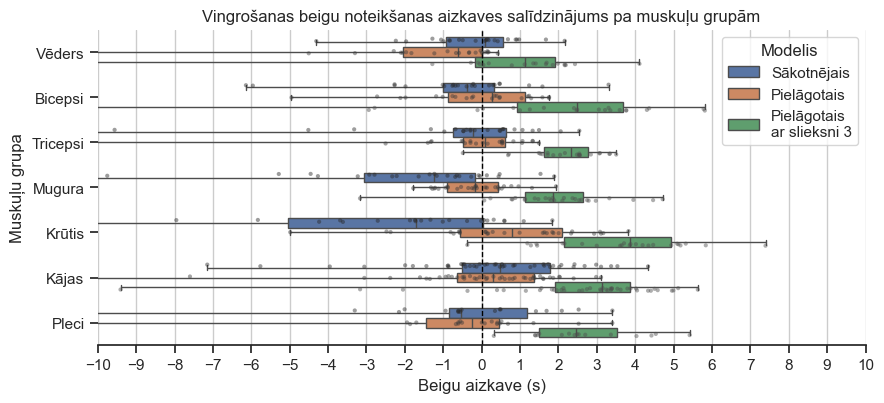

In [794]:
plot_latency_comparison_per_group(
    [latency_df,
     latency_df_finetuned,
     latency_df_finetuned_acc3],
    latency_col="end_latency_sec",
    xlabel="Beigu aizkave (s)",
    title="Vingrošanas beigu noteikšanas aizkaves salīdzinājums pa muskuļu grupām",
    xlim=(-10, 10),
    group_order=GROUP_ORDER
)

In [795]:
# plot_latency_comparison_per_group(
#     latency_df_finetuned,
#     latency_df_finetuned_acc3,
#     latency_col="start_latency_sec",
#     xlabel="Sākuma aizkave (s)",
#     title="",
#     xlim=(-10, 10),
#     group_order=GROUP_ORDER
# )

# RecoFit style metrics

## Methods

In [796]:
def count_good_single_fragment_segments(
    latency_df,
    thresholds=(2, 5),
    start_col="start_latency_sec",
    end_col="end_latency_sec",
    fragment_col="predicted_fragment_count"
):
    rows = []

    total_segments = len(latency_df)

    detected = latency_df[
        latency_df["status"].str.lower() == "detected"
    ].copy()

    for threshold in thresholds:
        good = detected[
            (detected[fragment_col] == 1) &
            (detected[start_col].abs() <= threshold) &
            (detected[end_col].abs() <= threshold)
        ]

        rows.append({
            "Robeža": f"±{threshold}s",
            "Segmenti kopā": total_segments,
            "Detektēti segmenti": len(detected),
            "Segmenti ar vienu fragmentu robežās": len(good),
            "Īpatsvars no visiem segmentiem (%)": len(good) / total_segments * 100,
            "Īpatsvars no detektētajiem segmentiem (%)": len(good) / len(detected) * 100 if len(detected) > 0 else 0
        })

    return pd.DataFrame(rows)

def good_single_fragment_stats_by(
    latency_df,
    by,
    thresholds=(2, 5),
    start_col="start_latency_sec",
    end_col="end_latency_sec",
    fragment_col="predicted_fragment_count"
):
    rows = []

    df = latency_df.copy()
    df["is_detected"] = df["status"].str.lower() == "detected"

    for group_value, group_df in df.groupby(by, dropna=False):
        total_segments = len(group_df)
        detected = group_df[group_df["is_detected"]].copy()

        for threshold in thresholds:
            good = detected[
                (detected[fragment_col] == 1) &
                (detected[start_col].abs() <= threshold) &
                (detected[end_col].abs() <= threshold)
            ]

            rows.append({
                by: group_value,
                "Robeža": f"±{threshold}s",
                "Segmenti kopā": total_segments,
                "Detektēti segmenti": len(detected),
                "Labi segmenti": len(good),
                "Īpatsvars no visiem segmentiem (%)": (
                    len(good) / total_segments * 100
                    if total_segments > 0 else 0
                ),
                "Īpatsvars no detektētajiem segmentiem (%)": (
                    len(good) / len(detected) * 100
                    if len(detected) > 0 else 0
                )
            })

    return pd.DataFrame(rows)

# Stats

In [797]:
latency_df = calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_binary"
)

latency_df_finetuned = calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_finetuned_binary"
)

latency_df_finetuned_acc3 = calculate_exercise_latency(
    df_acc_finetuned_3,
    events_df,
    prediction_col="prediction_finetuned_accumulator_3"
)

In [798]:
print("Sākotnējais modelis - vienas fragmentācijas segmentu statistika:")
single_fragment_latency_stats = count_good_single_fragment_segments(
    latency_df,
    thresholds=(2, 5)
)

display(single_fragment_latency_stats.style.format(decimal=",", precision=2))

print("Finetuned modelis - vienas fragmentācijas segmentu statistika:")
single_fragment_latency_stats_finetuned = count_good_single_fragment_segments(
    latency_df_finetuned,
    thresholds=(2, 5)
)

display(single_fragment_latency_stats_finetuned.style.format(decimal=",", precision=2))

print("Finetuned (Accumulator 3) modelis - vienas fragmentācijas segmentu statistika:")
single_fragment_latency_stats_finetuned_acc3 = count_good_single_fragment_segments(
    latency_df_finetuned_acc3,
    thresholds=(2, 5)
)

display(single_fragment_latency_stats_finetuned_acc3.style.format(decimal=",", precision=2))

Sākotnējais modelis - vienas fragmentācijas segmentu statistika:


,Robeža,Segmenti kopā,Detektēti segmenti,Segmenti ar vienu fragmentu robežās,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,±2s,197,187,25,"12,69","13,37"
1,±5s,197,187,36,"18,27","19,25"


Finetuned modelis - vienas fragmentācijas segmentu statistika:


,Robeža,Segmenti kopā,Detektēti segmenti,Segmenti ar vienu fragmentu robežās,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,±2s,197,192,64,"32,49","33,33"
1,±5s,197,192,94,"47,72","48,96"


Finetuned (Accumulator 3) modelis - vienas fragmentācijas segmentu statistika:


,Robeža,Segmenti kopā,Detektēti segmenti,Segmenti ar vienu fragmentu robežās,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,±2s,197,179,10,"5,08","5,59"
1,±5s,197,179,113,"57,36","63,13"


In [799]:
def combine_single_fragment_percent_overall(
    latency_dfs,
    model_names,
    thresholds=(2, 5)
):
    all_stats = []

    for latency_df, model_name in zip(latency_dfs, model_names):
        stats = count_good_single_fragment_segments(
            latency_df,
            thresholds=thresholds
        )

        stats["Modelis"] = model_name
        all_stats.append(stats)

    combined = pd.concat(all_stats, ignore_index=True)

    pivot = combined.pivot_table(
        index="Modelis",
        columns="Robeža",
        values="Īpatsvars no visiem segmentiem (%)"
    )

    return pivot.reset_index()

In [800]:
single_fragment_overall_percent_table = combine_single_fragment_percent_overall(
    latency_dfs=[
        latency_df,
        latency_df_finetuned,
        latency_df_finetuned_acc3
    ],
    model_names=[
        "Sākotnējais",
        "Pielāgotais",
        "Pielāgotais akumulators 3"
    ],
    thresholds=(2, 5)
)

display(
    single_fragment_overall_percent_table
        .style
        .format(decimal=",", precision=2)
)

Robeža,Modelis,±2s,±5s
0,Pielāgotais,"32,49","47,72"
1,Pielāgotais akumulators 3,"5,08","57,36"
2,Sākotnējais,"12,69","18,27"


In [801]:

print("Sākotnējais modelis - vienas fragmentācijas segmentu statistika:")
single_fragment_per_session = good_single_fragment_stats_by(
    latency_df,
    by="session_id",
    thresholds=(5,)
)

display(single_fragment_per_session.style.format(decimal=",", precision=2))

print("Finetuned modelis - vienas fragmentācijas segmentu statistika:")
single_fragment_per_session_finetuned = good_single_fragment_stats_by(
    latency_df_finetuned,
    by="session_id",
    thresholds=(5,)
)

display(single_fragment_per_session_finetuned.style.format(decimal=",", precision=2))

print("Finetuned (Accumulator 3) modelis - vienas fragmentācijas segmentu statistika:")
single_fragment_per_session_finetuned_acc3 = good_single_fragment_stats_by(
    latency_df_finetuned_acc3,
    by="session_id",
    thresholds=(5,)
)

display(single_fragment_per_session_finetuned_acc3.style.format(decimal=",", precision=2))

Sākotnējais modelis - vienas fragmentācijas segmentu statistika:


,session_id,Robeža,Segmenti kopā,Detektēti segmenti,Labi segmenti,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,1,±5s,22,19,9,"40,91","47,37"
1,2,±5s,16,16,1,"6,25","6,25"
2,3,±5s,16,15,2,"12,50","13,33"
3,4,±5s,16,15,3,"18,75","20,00"
4,5,±5s,20,19,2,"10,00","10,53"
5,6,±5s,32,30,4,"12,50","13,33"
6,7,±5s,18,16,3,"16,67","18,75"
7,8,±5s,16,16,2,"12,50","12,50"
8,9,±5s,18,18,7,"38,89","38,89"
9,10,±5s,23,23,3,"13,04","13,04"


Finetuned modelis - vienas fragmentācijas segmentu statistika:


,session_id,Robeža,Segmenti kopā,Detektēti segmenti,Labi segmenti,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,1,±5s,22,21,11,"50,00","52,38"
1,2,±5s,16,16,10,"62,50","62,50"
2,3,±5s,16,16,9,"56,25","56,25"
3,4,±5s,16,16,8,"50,00","50,00"
4,5,±5s,20,18,9,"45,00","50,00"
5,6,±5s,32,31,17,"53,12","54,84"
6,7,±5s,18,18,5,"27,78","27,78"
7,8,±5s,16,16,7,"43,75","43,75"
8,9,±5s,18,17,10,"55,56","58,82"
9,10,±5s,23,23,8,"34,78","34,78"


Finetuned (Accumulator 3) modelis - vienas fragmentācijas segmentu statistika:


,session_id,Robeža,Segmenti kopā,Detektēti segmenti,Labi segmenti,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,1,±5s,22,21,13,"59,09","61,90"
1,2,±5s,16,16,9,"56,25","56,25"
2,3,±5s,16,16,12,"75,00","75,00"
3,4,±5s,16,16,11,"68,75","68,75"
4,5,±5s,20,17,11,"55,00","64,71"
5,6,±5s,32,25,17,"53,12","68,00"
6,7,±5s,18,14,9,"50,00","64,29"
7,8,±5s,16,15,9,"56,25","60,00"
8,9,±5s,18,18,11,"61,11","61,11"
9,10,±5s,23,21,11,"47,83","52,38"


In [802]:
def combine_single_fragment_percent_per_session(
    latency_dfs,
    model_names,
    thresholds=(2, 5)
):
    all_stats = []

    for latency_df, model_name in zip(latency_dfs, model_names):
        stats = good_single_fragment_stats_by(
            latency_df,
            by="session_id",
            thresholds=thresholds
        )

        stats["Modelis"] = model_name
        all_stats.append(stats)

    combined = pd.concat(all_stats, ignore_index=True)

    # Keep only the percentage from all annotated segments
    pivot = combined.pivot_table(
        index="session_id",
        columns=["Modelis", "Robeža"],
        values="Īpatsvars no visiem segmentiem (%)"
    )

    # Optional: flatten column names
    pivot.columns = [
        f"{model} {threshold}"
        for model, threshold in pivot.columns
    ]

    return pivot.reset_index().rename(columns={
        "session_id": "Sesija"
    })

In [803]:
single_fragment_session_percent_table = combine_single_fragment_percent_per_session(
    latency_dfs=[
        latency_df,
        latency_df_finetuned,
        latency_df_finetuned_acc3
    ],
    model_names=[
        "Sākotnējais",
        "Pielāgotais",
        "Pielāgotais akumulators 3"
    ],
    thresholds=(5,)
)

display(
    single_fragment_session_percent_table
        .style
        .format(decimal=",", precision=2)
)

,Sesija,Pielāgotais ±5s,Pielāgotais akumulators 3 ±5s,Sākotnējais ±5s
0,1,"50,00","59,09","40,91"
1,2,"62,50","56,25","6,25"
2,3,"56,25","75,00","12,50"
3,4,"50,00","68,75","18,75"
4,5,"45,00","55,00","10,00"
5,6,"53,12","53,12","12,50"
6,7,"27,78","50,00","16,67"
7,8,"43,75","56,25","12,50"
8,9,"55,56","61,11","38,89"
9,10,"34,78","47,83","13,04"


# post processing

In [804]:
def evaluate_postprocessing_methods(
    model_dfs,
    events_df,
    truth_col="ground_truth",
    timestamp_col="timestamp",
    max_gap_ms=3000
):
    """
    model_dfs:
        dict where key = model/method name,
        value = tuple(df, prediction_col)

        Example:
        {
            "Sākotnējais": (raw_df, "prediction_binary"),
            "Pielāgotais": (finetuned_df, "prediction_binary"),
            "Pielāgotais + akumulators 3": (finetuned_acc3_df, "prediction_accumulator"),
            "Pielāgotais + inerce": (finetuned_inertia_df, "prediction_inertia"),
        }
    """

    classification_rows = []
    fragmentation_rows = []
    start_latency_rows = []
    end_latency_rows = []
    false_activation_rows = []

    latency_dfs = {}

    for model_name, (df, prediction_col) in model_dfs.items():

        # -------------------------
        # 1. Classification metrics
        # -------------------------
        cls = classification_report_summary_table(
            df,
            truth_col=truth_col,
            prediction_col=prediction_col
        )

        classification_rows.append({
            "Modelis": model_name,
            "Precizitāte (vingro)": cls["precision_1"],
            "Pārklājums (vingro)": cls["recall_1"],
            "F1 (vingro)": cls["f1_1"],
            "F1 (nevingro)": cls["f1_0"],
            "Vidējais F1": cls["f1_macro"],
        })

        # -------------------------
        # 2. Fragmentation metrics
        # -------------------------
        exercise_segments = get_exercise_segments(df, events_df)

        fragmentation_df = calculate_fragmentation(
            exercise_segments,
            prediction_col=prediction_col
        )

        frag_stats = calculate_fragmentation_statistics(fragmentation_df)

        fragmentation_rows.append({
            "Modelis": model_name,
            "Segmenti ar 1 fragmentu (%)": frag_stats.loc["Segmenti ar 1 fragmentu (%)", 0],
            "Vidējais fragmentu skaits": frag_stats.loc["Vidējais", 0],
            "Maksimālais fragmentu skaits": frag_stats.loc["Maksimālais", 0],
            "Nenoteikti segmenti (%)": frag_stats.loc["Nenoteikti segmenti (%)", 0],
        })

        # -------------------------
        # 3. Latency metrics
        # -------------------------
        latency_df = calculate_exercise_latency(
            windows_df=df,
            events_df=events_df,
            prediction_col=prediction_col,
            timestamp_col=timestamp_col,
            max_gap_ms=max_gap_ms
        )

        latency_df = latency_df.copy()
        latency_df["Modelis"] = model_name
        latency_dfs[model_name] = latency_df

        start_stats = calculate_latency_statistics(
            latency_df,
            latency_col="start_latency_sec"
        )

        end_stats = calculate_latency_statistics(
            latency_df,
            latency_col="end_latency_sec"
        )

        start_latency_rows.append({
            "Modelis": model_name,
            "Vidējā sākuma aizkave (s)": start_stats.loc["Vidējais", 0],
            "Mediānā sākuma aizkave (s)": start_stats.loc["Mediāna", 0],
            "P95 sākuma aizkave (s)": start_stats.loc["P95", 0],
            "Detektēti segmenti (%)": start_stats.loc["Detektēti segmenti (%)", 0],
            "Sākuma aizkave ≤ 3 s (%)": start_stats.loc["Aizkave ≤ 3 s (%)", 0],
            "Sākuma aizkave ≤ 5 s (%)": start_stats.loc["Aizkave ≤ 5 s (%)", 0],
        })

        end_latency_rows.append({
            "Modelis": model_name,
            "Vidējā beigu aizkave (s)": end_stats.loc["Vidējais", 0],
            "Mediānā beigu aizkave (s)": end_stats.loc["Mediāna", 0],
            "P95 beigu aizkave (s)": end_stats.loc["P95", 0],
            "Detektēti segmenti (%)": end_stats.loc["Detektēti segmenti (%)", 0],
            "Beigu aizkave ≤ 3 s (%)": end_stats.loc["Aizkave ≤ 3 s (%)", 0],
            "Beigu aizkave ≤ 5 s (%)": end_stats.loc["Aizkave ≤ 5 s (%)", 0],
        })

        # -------------------------
        # 4. False rest activations
        # -------------------------
        rest_segments = get_rest_segments(df)

        rest_activation_df, false_activation_runs = calculate_false_rest_activations(
            rest_segments,
            prediction_col=prediction_col
        )

        rest_stats = calculate_rest_activation_statistics(
            rest_activation_df,
            false_activation_runs
        )

        false_activation_rows.append({
            "Modelis": model_name,
            "Vidējais aktivizāciju skaits atpūtas segmentā":
                rest_stats.loc[0, "Vidējais"],
            "Mediānais aktivizāciju skaits atpūtas segmentā":
                rest_stats.loc[0, "Mediānais"],
            "Aktivizācijas minūtē":
                rest_stats.loc[0, "Vidējās aktivizācijas minūtē"],
            "Vidējais aktivizāciju ilgums (s)":
                rest_stats.loc[0, "Vidējais aktivizāciju ilgums (s)"],
            "Mediānais aktivizācijas ilgums (s)":
                rest_stats.loc[0, "Mediānais aktivizācijas ilgums (s)"],
            "Atpūtas segmenti ar kļūdainām aktivizācijām (%)":
                rest_stats.loc[0, "Kļūdaino aktivizāciju īpatsvars (%)"],
        })

    results = {
        "classification": pd.DataFrame(classification_rows),
        "fragmentation": pd.DataFrame(fragmentation_rows),
        "start_latency": pd.DataFrame(start_latency_rows),
        "end_latency": pd.DataFrame(end_latency_rows),
        "false_activations": pd.DataFrame(false_activation_rows),
        "latency_dfs": latency_dfs,
    }

    return results

In [805]:
def apply_hysteresis(
    df,
    prob_col="prediction_float",
    output_col="prediction_hysteresis",
    enter_threshold=0.6,
    exit_threshold=0.3,
    group_cols=("session_id",)
):
    df = df.copy()
    df[output_col] = 0

    group_cols = [col for col in group_cols if col in df.columns]
    grouped = df.groupby(group_cols, sort=False) if group_cols else [(None, df)]

    for _, group_df in grouped:
        state = 0
        states = []

        probs = group_df[prob_col].fillna(0).to_numpy()

        for prob in probs:
            if state == 0 and prob >= enter_threshold:
                state = 1
            elif state == 1 and prob <= exit_threshold:
                state = 0

            states.append(state)

        df.loc[group_df.index, output_col] = states

    return df

In [806]:
df_hyster = apply_hysteresis(
    windows_df,
    prob_col="prediction_finetuned_float",
    output_col="prediction_hysteresis"
)

df_hyster = apply_accumulator_aggregation(
    df_hyster,
    threshold=3,
    prediction_col="prediction_hysteresis",
    output_col="prediction_hysteresis_acc_3"
)

df_hyster = apply_inertia_aggregation(
    df_hyster,
    prediction_col="prediction_hysteresis",
    output_col="prediction_hysteresis_inertia_1_5",
    enter_threshold=1,
    max_accumulator=5,
)

df_hyster = apply_inertia_aggregation(
    df_hyster,
    prediction_col="prediction_hysteresis",
    output_col="prediction_hysteresis_inertia_2_5",
    enter_threshold=2,
    max_accumulator=5,
)

In [807]:
df_inertia = apply_inertia_aggregation(
    windows_df,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_inertia_1_5",
    enter_threshold=1,
    max_accumulator=5,
)

df_inertia = apply_inertia_aggregation(
    df_inertia,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_inertia_2_5",
    enter_threshold=2,
    max_accumulator=5,
)

df_inertia = apply_inertia_aggregation(
    df_inertia,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_inertia_1_10",
    enter_threshold=1,
    max_accumulator=10,
)

df_inertia = apply_inertia_aggregation(
    df_inertia,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_inertia_2_10",
    enter_threshold=2,
    max_accumulator=10,
)

In [838]:
model_dfs = {
    "Sākotnējais": (windows_df, "prediction_binary"),
    "Pielāgotais": (windows_df, "prediction_finetuned_binary"),
    "hysterisis": (df_hyster, "prediction_hysteresis"),
    "hysteresis + acc 3": (df_hyster, "prediction_hysteresis_acc_3"),
    "Pielāgotais + akumulators 3": (df_acc_finetuned_3, "prediction_finetuned_accumulator_3"),
    "inerce 1 10": (df_inertia, "prediction_inertia_1_10"),
    "inerce 2 10": (df_inertia, "prediction_inertia_2_10"),
    "inerce 1 5": (df_inertia, "prediction_inertia_1_5"),
    "inerce 2 5": (df_inertia, "prediction_inertia_2_5"),
    "hysterisis + inerce 1 5": (df_hyster, "prediction_hysteresis_inertia_1_5"),
    "hysterisis + inerce 2 5": (df_hyster, "prediction_hysteresis_inertia_2_5"),

}

comparison = evaluate_postprocessing_methods(
    model_dfs=model_dfs,
    events_df=events_df
)

In [839]:
display(comparison["classification"].round(3))
display(comparison["fragmentation"].round(2))
display(comparison["start_latency"].round(2))
display(comparison["end_latency"].round(2))
display(comparison["false_activations"].round(2))

,Modelis,Precizitāte (vingro),Pārklājums (vingro),F1 (vingro),F1 (nevingro),Vidējais F1
0,Sākotnējais,0.571,0.627,0.598,0.924,0.761
1,Pielāgotais,0.718,0.819,0.765,0.955,0.860
2,hysterisis,0.723,0.842,0.778,0.957,0.867
3,hysteresis + acc 3,0.735,0.824,0.777,0.958,0.867
4,Pielāgotais + akumulators 3,0.759,0.809,0.783,0.960,0.871
5,inerce 1 10,0.573,0.889,0.697,0.928,0.812
6,inerce 2 10,0.604,0.863,0.711,0.935,0.823
7,inerce 1 5,0.631,0.886,0.737,0.942,0.839
8,inerce 2 5,0.674,0.860,0.756,0.949,0.853
9,hysterisis + inerce 1 5,0.627,0.890,0.736,0.941,0.838


,Modelis,Segmenti ar 1 fragmentu (%),Vidējais fragmentu skaits,Maksimālais fragmentu skaits,Nenoteikti segmenti (%)
0,Sākotnējais,25.38,3.91,16.0,5.58
1,Pielāgotais,54.31,2.34,13.0,2.54
2,hysterisis,65.99,1.65,10.0,2.54
3,hysteresis + acc 3,83.76,1.07,4.0,6.09
4,Pielāgotais + akumulators 3,78.68,1.05,4.0,9.64
5,inerce 1 10,83.76,1.34,9.0,2.03
6,inerce 2 10,86.80,1.06,3.0,4.57
7,inerce 1 5,82.74,1.35,9.0,2.03
8,inerce 2 5,85.79,1.07,3.0,4.57
9,hysterisis + inerce 1 5,83.76,1.20,7.0,2.03


,Modelis,Vidējā sākuma aizkave (s),Mediānā sākuma aizkave (s),P95 sākuma aizkave (s),Detektēti segmenti (%),Sākuma aizkave ≤ 3 s (%),Sākuma aizkave ≤ 5 s (%)
0,Sākotnējais,2.02,0.98,9.70,94.92,74.33,85.56
1,Pielāgotais,0.63,0.71,3.68,97.46,80.73,89.58
2,hysterisis,0.61,0.82,6.07,97.46,75.52,86.46
3,hysteresis + acc 3,1.56,2.64,7.82,93.91,44.86,79.46
4,Pielāgotais + akumulators 3,1.35,2.62,7.17,90.86,46.37,82.68
5,inerce 1 10,-1.69,0.40,3.21,97.97,67.36,75.65
6,inerce 2 10,-0.67,1.34,6.72,95.43,57.98,77.13
7,inerce 1 5,-0.96,0.43,3.21,97.97,69.43,78.24
8,inerce 2 5,0.07,1.41,6.72,95.43,59.57,80.32
9,hysterisis + inerce 1 5,-0.65,0.56,5.54,97.97,66.32,78.24


,Modelis,Vidējā beigu aizkave (s),Mediānā beigu aizkave (s),P95 beigu aizkave (s),Detektēti segmenti (%),Beigu aizkave ≤ 3 s (%),Beigu aizkave ≤ 5 s (%)
0,Sākotnējais,-1.44,-0.38,2.49,94.92,80.75,90.37
1,Pielāgotais,-0.42,0.05,2.38,97.46,90.62,96.35
2,hysterisis,-0.25,0.23,3.03,97.46,87.50,94.79
3,hysteresis + acc 3,1.76,2.53,5.56,93.91,56.22,87.03
4,Pielāgotais + akumulators 3,1.54,2.42,5.12,90.86,59.22,90.50
5,inerce 1 10,9.15,9.58,15.53,97.97,5.70,8.81
6,inerce 2 10,9.38,9.58,15.80,95.43,2.66,5.85
7,inerce 1 5,3.92,4.45,7.71,97.97,16.58,56.48
8,inerce 2 5,4.01,4.50,7.74,95.43,13.83,54.79
9,hysterisis + inerce 1 5,4.09,4.55,8.42,97.97,11.40,53.89


,Modelis,Vidējais aktivizāciju skaits atpūtas segmentā,Mediānais aktivizāciju skaits atpūtas segmentā,Aktivizācijas minūtē,Vidējais aktivizāciju ilgums (s),Mediānais aktivizācijas ilgums (s),Atpūtas segmenti ar kļūdainām aktivizācijām (%)
0,Sākotnējais,7.35,5.0,2.46,2.01,1.01,88.79
1,Pielāgotais,4.18,3.0,1.54,2.38,1.01,81.61
2,hysterisis,3.11,2.0,1.30,3.23,2.01,78.92
3,hysteresis + acc 3,1.76,1.0,0.97,5.24,4.01,79.82
4,Pielāgotais + akumulators 3,1.58,1.0,0.76,5.07,3.02,75.34
5,inerce 1 10,3.89,3.0,1.72,5.34,3.02,90.13
6,inerce 2 10,2.25,2.0,1.13,7.87,6.05,87.89
7,inerce 1 5,4.03,3.0,1.83,4.01,3.02,89.69
8,inerce 2 5,2.30,2.0,1.16,5.62,4.03,87.00
9,hysterisis + inerce 1 5,3.19,2.0,inf,5.18,3.02,89.69


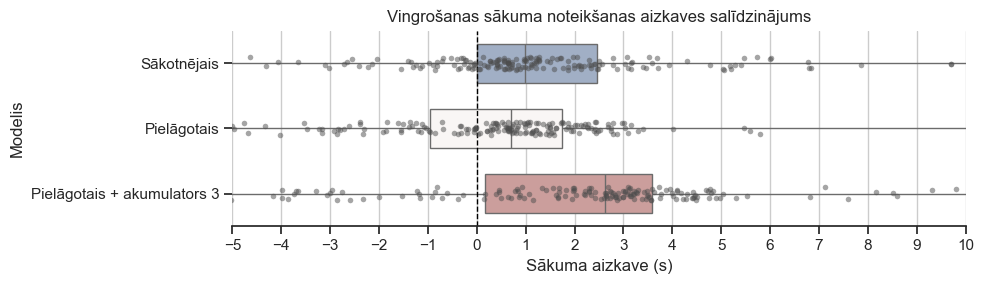

In [814]:
plot_latency_comparison_combined(
    list(comparison["latency_dfs"].values()),
    latency_col="start_latency_sec",
    xlabel="Sākuma aizkave (s)",
    ylabel="Modelis",
    title="Vingrošanas sākuma noteikšanas aizkaves salīdzinājums",
    xlim=(-5, 10)
)

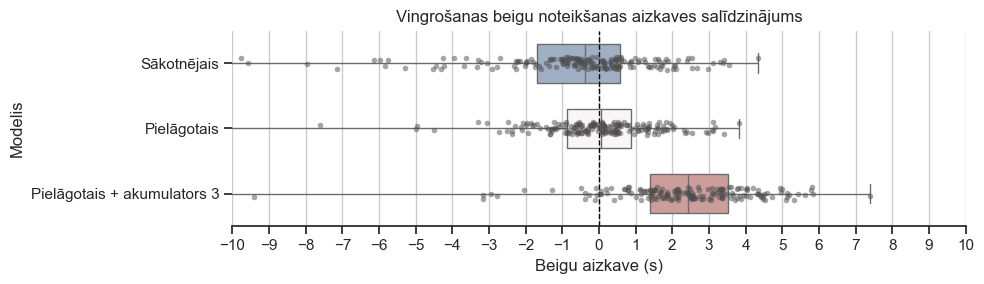

In [815]:
plot_latency_comparison_combined(
    list(comparison["latency_dfs"].values()),
    latency_col="end_latency_sec",
    xlabel="Beigu aizkave (s)",
    ylabel="Modelis",
    title="Vingrošanas beigu noteikšanas aizkaves salīdzinājums",
    xlim=(-10, 10)
)